# SLEAP × mPFC Spike Exploration
Correlates continuous mPFC firing rates with SLEAP-derived social features.

**Alignment**: SLEAP `time_ms` is used to bin features into 50ms windows matching the spike timebin.  
**Unit-level**: Spearman r between each unit's firing rate and each feature, across all timepoints.  
**Population-level**: Spearman r between mean firing rate across all units and each feature, per session.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy import stats
import sys
import os

from spike.spike_analysis.spike_collection import SpikeCollection

## Load data

In [3]:
SPIKE_COLLECTION_NOVEL_PATH = r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\novel_collection'
SLEAP_DICT_NOVEL_PATH       = r'C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\pilot2\habit_dishabit_phase1\novel_sleap_dict.pkl'

novel_collection = SpikeCollection.load_collection(SPIKE_COLLECTION_NOVEL_PATH)
with open(SLEAP_DICT_NOVEL_PATH, 'rb') as f:
    novel_dicts = pickle.load(f)

SPIKE_COLLECTION_CAGEMATE_PATH = r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\cagemate_collection'
SLEAP_DICT_CAGEMATE_PATH       = r'C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\pilot2\habit_dishabit_phase1\cage_sleap_dict.pkl'

cagemate_collection = SpikeCollection.load_collection(SPIKE_COLLECTION_CAGEMATE_PATH)
with open(SLEAP_DICT_CAGEMATE_PATH, 'rb') as f:
    cage_dicts = pickle.load(f)






## Analyze spike collection at 50ms

In [4]:
TIMEBIN = 50  # ms

cagemate_collection.analyze(
    timebin=TIMEBIN,
    ignore_freq=0.5,
    smoothing_window=None,
    mode='same'
)

novel_collection.analyze(
    timebin=TIMEBIN,
    ignore_freq=0.5,
    smoothing_window=None,
    mode='same'
)


All set to analyze
All set to analyze


## Alignment helpers

In [5]:
def build_spike_time_axis(recording, timebin):
    """
    Returns the start time in ms for each spike timebin.
    Uses first_timestamp (in samples) if available, otherwise assumes recording starts at 0.
    """
    n_timebins = len(next(iter(recording.unit_firing_rates.values())))
    start_ms = 0
    return start_ms + np.arange(n_timebins) * timebin  # [n_timebins] #[0, 50, 100, 150] etc. for 50 ms timebin



def bin_sleap_to_spike(sleap_time_ms, sleap_features, spike_time_ms, timebin):
      n_timebins = len(spike_time_ms)
      n_features = sleap_features.shape[1]
      binned     = np.full((n_timebins, n_features), np.nan)

      bin_indices = np.digitize(sleap_time_ms, spike_time_ms) - 1 # figures out which bin each 1ms sleap pose goes into 0-50 = first bin, 50-100 - second bin, minus 1 = 0 indexed?
      valid       = (bin_indices >= 0) & (bin_indices < n_timebins)

      # vectorized grouped mean using pandas (fastest for this pattern)
      import pandas as pd
      df = pd.DataFrame(sleap_features[valid],
                        index=bin_indices[valid])
      means = df.groupby(level=0).mean()

      binned[means.index.values] = means.values
      return binned

In [6]:
cage_dicts.keys()

dict_keys(['11_cage_p1_aggregated', '12_cage_p1_aggregated', '13_cage_p1_aggregated', '21_cage_p1_aggregated', '22_cage_p1_aggregated', '23_cage_p1_aggregated', '24_cage_p1_aggregated', '31_cage_p1_aggregated', '32_cage_p1_aggregated', '33_cage_p1_aggregated', '41_cage_p1_aggregated', '44_cage_p1_aggregated'])

## Compute correlations

In [7]:
unit_corr_rows  = []   # one row per unit per feature
pop_corr_rows   = []   # one row per session per feature

for recording in cagemate_collection.recordings:
    rec_name = recording.name.replace( 'merged.rec','aggregated')
    subject  = getattr(recording, 'subject', rec_name)

    if rec_name not in cage_dicts:
        print(f'No SLEAP data for {rec_name}, skipping')
        continue

    if recording.analyzed_neurons == 0:
        print(f'{rec_name}: 0 analyzed neurons, skipping')
        continue

    # build spike time axis
    spike_time_ms = build_spike_time_axis(recording, TIMEBIN)
    n_timebins    = len(spike_time_ms)

    # stack all SLEAP agents for this recording into one continuous feature array
    # (agent here is cagemate/novel/familiar — pooling all social bouts)
    all_sleap_time     = []
    all_sleap_features = []
    feature_legend     = None

    for agent, agent_info in cage_dicts[rec_name].items():
        all_sleap_time.append(agent_info['time_ms'])
        all_sleap_features.append(agent_info['features_1ms'])
        feature_legend = agent_info['feature_legend']

    sleap_time_ms  = np.concatenate(all_sleap_time)
    sleap_features = np.vstack(all_sleap_features)

    # sort by time (concatenating agents can scramble order)
    sort_idx       = np.argsort(sleap_time_ms)
    sleap_time_ms  = sleap_time_ms[sort_idx]
    sleap_features = sleap_features[sort_idx]

    # bin SLEAP to spike timebin resolution
    binned_features = bin_sleap_to_spike(sleap_time_ms, sleap_features, spike_time_ms, TIMEBIN)
    # [n_timebins, n_features]

    # build population firing rate vector [n_timebins]
    fr_matrix = np.array([recording.unit_firing_rates[u] for u in recording.unit_firing_rates])  # [n_units, n_timebins]
    pop_fr    = np.nanmean(fr_matrix, axis=0)  # [n_timebins]

    # valid timepoints: SLEAP coverage exists + no NaN in population FR
    valid_mask = ~np.any(np.isnan(binned_features), axis=1) & ~np.isnan(pop_fr)

    if valid_mask.sum() < 10:
        print(f'{rec_name}: too few valid timepoints ({valid_mask.sum()}), skipping')
        continue

    # --- per-unit correlations ---
    for unit_id, fr in recording.unit_firing_rates.items():
        unit_mask = valid_mask & ~np.isnan(fr)
        if unit_mask.sum() < 10:
            continue
        for feat_idx, feat_name in enumerate(feature_legend):
            r, p = spearmanr(fr[unit_mask], binned_features[unit_mask, feat_idx])
            unit_corr_rows.append({
                'subject':   subject,
                'recording': rec_name,
                'unit_id':   unit_id,
                'feature':   feat_name,
                'spearman_r': r,
                'pval':      p,
            })

    # --- population correlations ---
    for feat_idx, feat_name in enumerate(feature_legend):
        r, p = spearmanr(pop_fr[valid_mask], binned_features[valid_mask, feat_idx])
        pop_corr_rows.append({
            'subject':    subject,
            'recording':  rec_name,
            'feature':    feat_name,
            'spearman_r': r,
            'pval':       p,
        })

cage_unit_corr_df = pd.DataFrame(unit_corr_rows)
cage_pop_corr_df  = pd.DataFrame(pop_corr_rows)

print(f'Unit correlations: {len(cage_unit_corr_df)} rows')
print(f'Population correlations: {len(cage_pop_corr_df)} rows')


Unit correlations: 1474 rows
Population correlations: 121 rows


In [8]:
unit_corr_rows  = []   # one row per unit per feature
pop_corr_rows   = []   # one row per session per feature

for recording in novel_collection.recordings:
    rec_name = recording.name.replace( 'merged.rec','aggregated')
    subject  = getattr(recording, 'subject', rec_name)

    if rec_name not in novel_dicts:
        print(f'No SLEAP data for {rec_name}, skipping')
        continue

    if recording.analyzed_neurons == 0:
        print(f'{rec_name}: 0 analyzed neurons, skipping')
        continue

    # build spike time axis
    spike_time_ms = build_spike_time_axis(recording, TIMEBIN)
    n_timebins    = len(spike_time_ms)

    # stack all SLEAP agents for this recording into one continuous feature array
    # (agent here is novel/novel/familiar — pooling all social bouts)
    all_sleap_time     = []
    all_sleap_features = []
    feature_legend     = None

    for agent, agent_info in novel_dicts[rec_name].items():
        all_sleap_time.append(agent_info['time_ms'])
        all_sleap_features.append(agent_info['features_1ms'])
        feature_legend = agent_info['feature_legend']

    sleap_time_ms  = np.concatenate(all_sleap_time)
    sleap_features = np.vstack(all_sleap_features)

    # sort by time (concatenating agents can scramble order)
    sort_idx       = np.argsort(sleap_time_ms)
    sleap_time_ms  = sleap_time_ms[sort_idx]
    sleap_features = sleap_features[sort_idx]

    # bin SLEAP to spike timebin resolution
    binned_features = bin_sleap_to_spike(sleap_time_ms, sleap_features, spike_time_ms, TIMEBIN)
    # [n_timebins, n_features]

    # build population firing rate vector [n_timebins]
    fr_matrix = np.array([recording.unit_firing_rates[u] for u in recording.unit_firing_rates])  # [n_units, n_timebins]
    pop_fr    = np.nanmean(fr_matrix, axis=0)  # [n_timebins]

    # valid timepoints: SLEAP coverage exists + no NaN in population FR
    valid_mask = ~np.any(np.isnan(binned_features), axis=1) & ~np.isnan(pop_fr)

    if valid_mask.sum() < 10:
        print(f'{rec_name}: too few valid timepoints ({valid_mask.sum()}), skipping')
        continue

    # --- per-unit correlations ---
    for unit_id, fr in recording.unit_firing_rates.items():
        unit_mask = valid_mask & ~np.isnan(fr)
        if unit_mask.sum() < 10:
            continue
        for feat_idx, feat_name in enumerate(feature_legend):
            r, p = spearmanr(fr[unit_mask], binned_features[unit_mask, feat_idx])
            unit_corr_rows.append({
                'subject':   subject,
                'recording': rec_name,
                'unit_id':   unit_id,
                'feature':   feat_name,
                'spearman_r': r,
                'pval':      p,
            })

    # --- population correlations ---
    for feat_idx, feat_name in enumerate(feature_legend):
        r, p = spearmanr(pop_fr[valid_mask], binned_features[valid_mask, feat_idx])
        pop_corr_rows.append({
            'subject':    subject,
            'recording':  rec_name,
            'feature':    feat_name,
            'spearman_r': r,
            'pval':       p,
        })

novel_unit_corr_df = pd.DataFrame(unit_corr_rows)
novel_pop_corr_df  = pd.DataFrame(pop_corr_rows)

print(f'Unit correlations: {len(novel_unit_corr_df)} rows')
print(f'Population correlations: {len(novel_pop_corr_df)} rows')


Unit correlations: 1441 rows
Population correlations: 110 rows


## Plot: per-unit Spearman r (n = units)

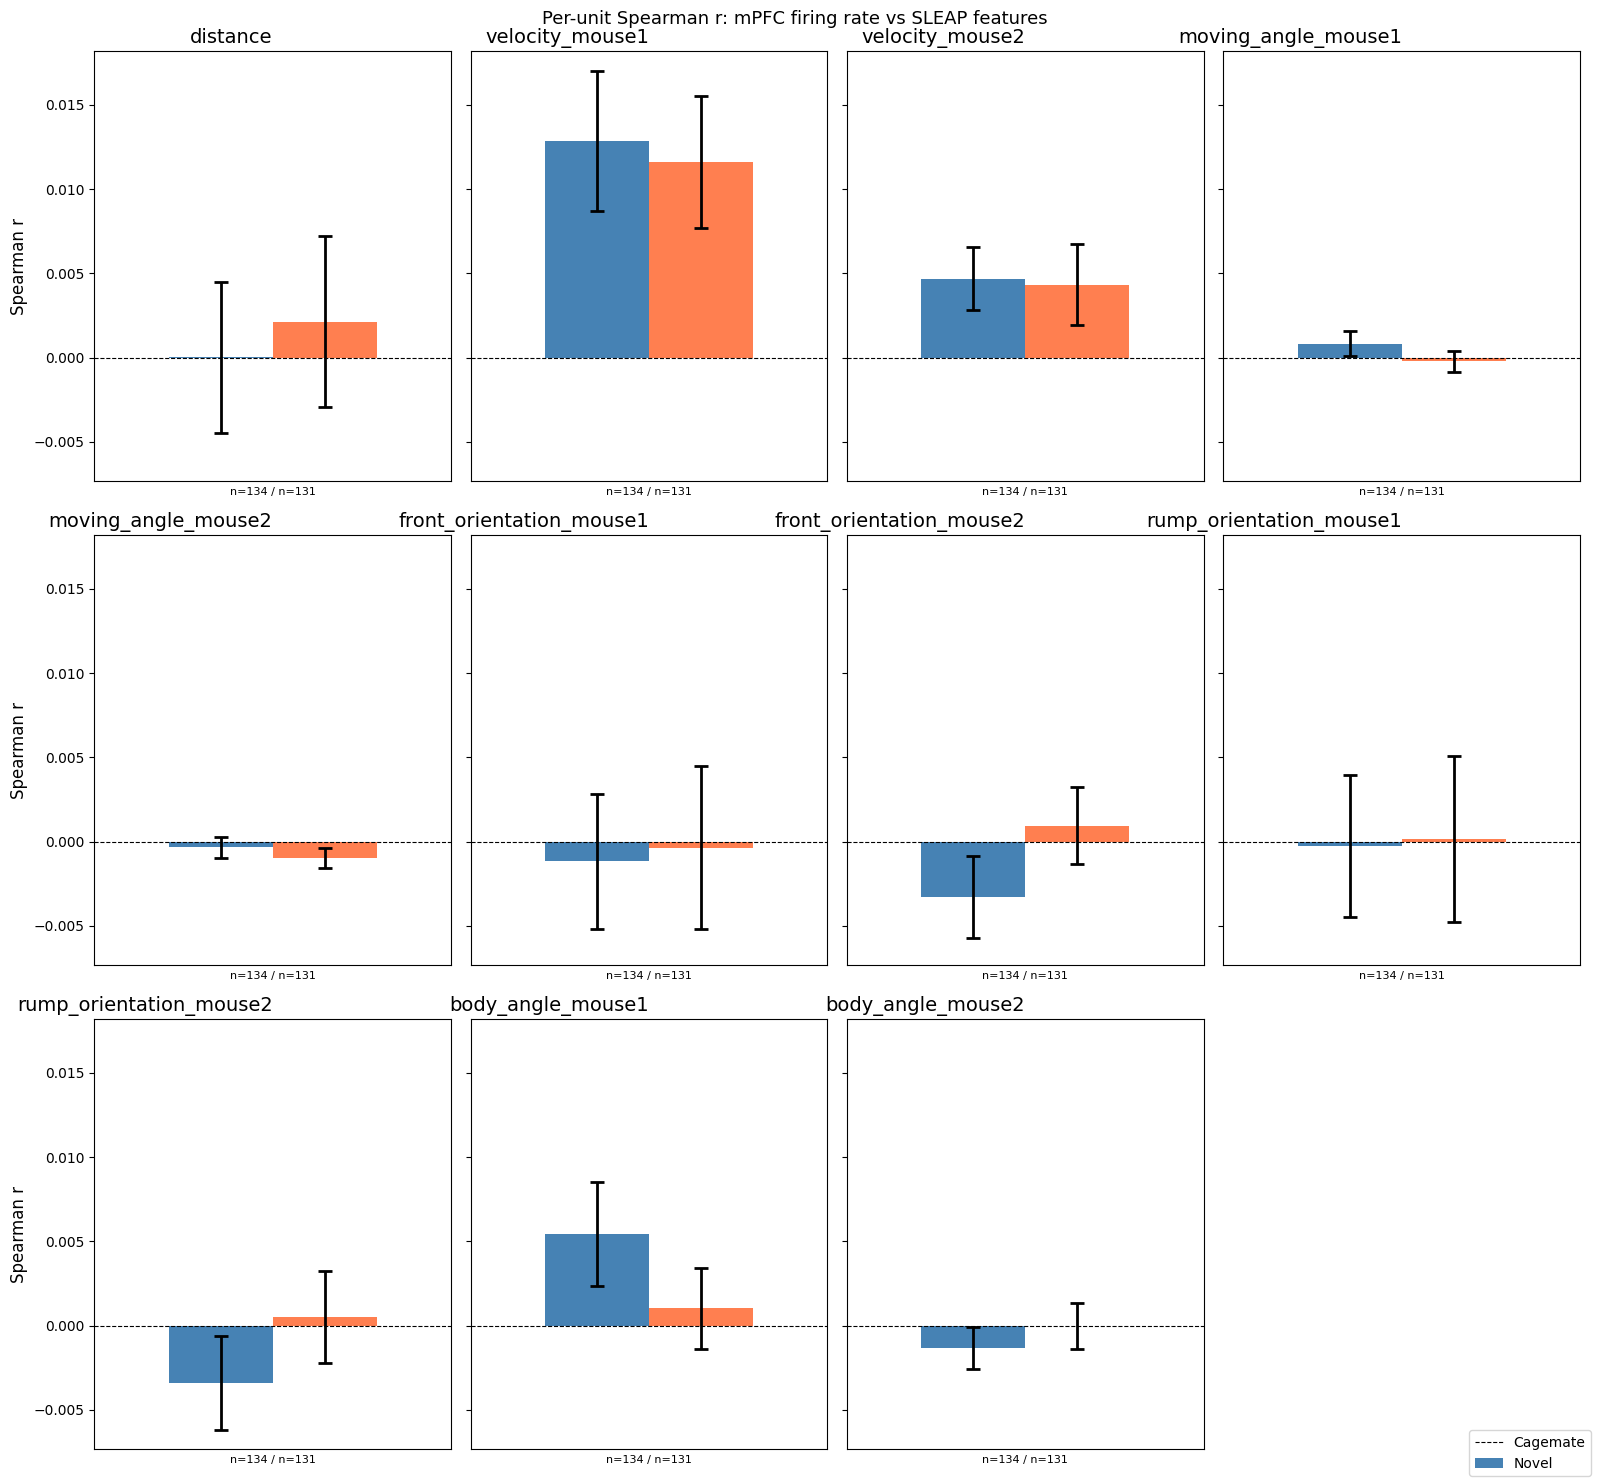

In [9]:
import math

features = cage_unit_corr_df['feature'].unique()
n_features = len(features)

n_cols = min(4, n_features)
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).flatten()

bar_width = 0.35
offsets = [-bar_width / 2, bar_width / 2]
colors = ['steelblue', 'coral']
labels = ['Cagemate', 'Novel']  # customize as needed
dfs = [cage_unit_corr_df, novel_unit_corr_df]          # your two dataframes

for ax, feat in zip(axes, features):
    for i, df in enumerate(dfs):
        vals = df[df['feature'] == feat]['spearman_r'].values
        mean = np.nanmean(vals)
        sem  = stats.sem(vals, nan_policy='omit')
        n    = len(vals)

        ax.bar(offsets[i], mean, yerr=sem, capsize=5, color=colors[i],
               width=bar_width, label=labels[i] if feat == features[0] else None,
               error_kw={'elinewidth': 2, 'capthick': 2})

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=14, rotation=0, ha='right')
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)

    n1 = len(dfs[0][dfs[0]['feature'] == feat]['spearman_r'].values)
    n2 = len(dfs[1][dfs[1]['feature'] == feat]['spearman_r'].values)
    ax.set_xlabel(f'n={n1} / n={n2}', fontsize=8)

for ax in axes[n_features:]:
    ax.set_visible(False)

for row in range(n_rows):
    axes[row * n_cols].set_ylabel('Spearman r', fontsize=12)

fig.suptitle('Per-unit Spearman r: mPFC firing rate vs SLEAP features', fontsize=13)
fig.legend(labels, loc='lower right', fontsize=10, framealpha=0.8)
plt.tight_layout()
plt.show()

## Plot: population Spearman r (n = sessions)

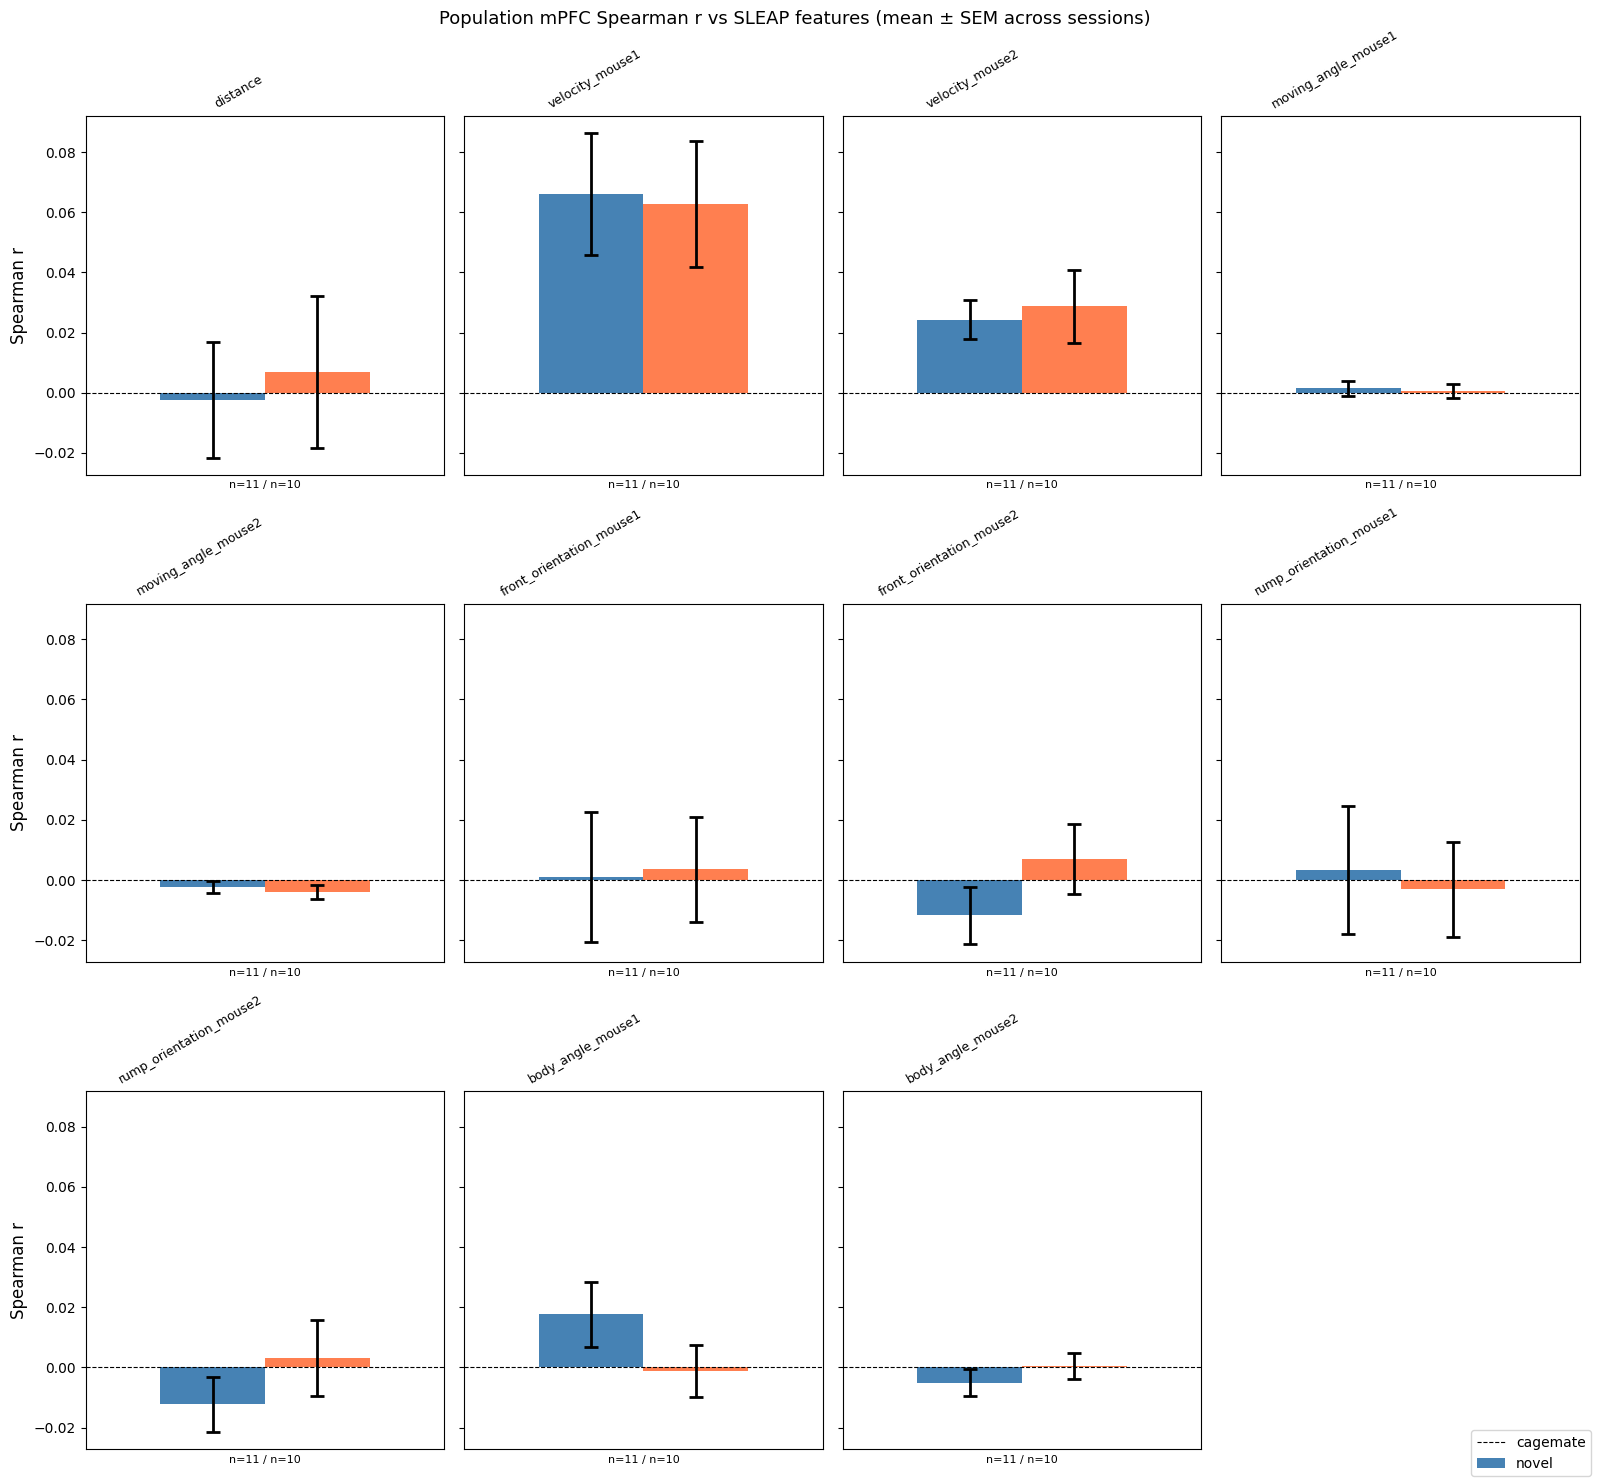

In [10]:
n_cols = min(4, n_features)
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).flatten()

bar_width = 0.35
offsets = [-bar_width / 2, bar_width / 2]
colors = ['steelblue', 'coral']
labels = ['cagemate', 'novel']
dfs = [cage_pop_corr_df, novel_pop_corr_df]

for ax, feat in zip(axes, features):
    for i, df in enumerate(dfs):
        vals = df[df['feature'] == feat]['spearman_r'].values
        mean = np.nanmean(vals)
        sem  = stats.sem(vals, nan_policy='omit')

        ax.bar(offsets[i], mean, yerr=sem, capsize=5, color=colors[i],
               width=bar_width, label=labels[i] if feat == features[0] else None,
               error_kw={'elinewidth': 2, 'capthick': 2})

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=9, rotation=30, ha='right')
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)

    n1 = len(dfs[0][dfs[0]['feature'] == feat]['spearman_r'].values)
    n2 = len(dfs[1][dfs[1]['feature'] == feat]['spearman_r'].values)
    ax.set_xlabel(f'n={n1} / n={n2}', fontsize=8)

for ax in axes[n_features:]:
    ax.set_visible(False)

for row in range(n_rows):
    axes[row * n_cols].set_ylabel('Spearman r', fontsize=12)

fig.suptitle('Population mPFC Spearman r vs SLEAP features (mean ± SEM across sessions)', fontsize=13)
fig.legend(labels, loc='lower right', fontsize=10, framealpha=0.8)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
from tqdm import tqdm

def mi_fast(x, y, n_bins=10):
    """Fast MI using numpy histogram2d — skips all sklearn overhead."""
    hist, _, _ = np.histogram2d(x, y, bins=n_bins)
    hist = hist / hist.sum()
    px = hist.sum(axis=1, keepdims=True)
    py = hist.sum(axis=0, keepdims=True)
    mask = hist > 0
    return float(np.sum(hist[mask] * np.log(hist[mask] / (px * py)[mask])))

def compute_mi_baselined(firing_rate, stimulus, n_bins=10, n_shuffles=100):
    actual_mi = mi_fast(firing_rate, stimulus, n_bins)
    shuffled_mis = np.array([
        mi_fast(firing_rate, np.random.permutation(stimulus), n_bins)
        for _ in range(n_shuffles)
    ])
    return actual_mi - shuffled_mis.mean()

N_SHUFFLES = 100
AGENTS     = ['exp1', 'exp4', 'exp5']

def calculate_mi_baselined(spike_collection, events, sleap_dicts):
    unit_corr_rows = []
    pop_corr_rows  = []
    unit_mi_rows   = []
    pop_mi_rows    = []

    for recording in tqdm(spike_collection.recordings, desc='recordings'):
        rec_name = recording.name.replace('merged.rec', 'aggregated')
        subject  = getattr(recording, 'subject', rec_name)

        if rec_name not in sleap_dicts:
            print(f'No SLEAP data for {rec_name}, skipping')
            continue
        if recording.analyzed_neurons == 0:
            print(f'{rec_name}: 0 analyzed neurons, skipping')
            continue

        spike_time_ms = build_spike_time_axis(recording, TIMEBIN)
        fr_matrix     = np.array([recording.unit_firing_rates[u]
                                for u in recording.unit_firing_rates])
        pop_fr        = np.nanmean(fr_matrix, axis=0)

        for agent, agent_info in sleap_dicts[rec_name].items():
            sleap_time_ms  = agent_info['time_ms']
            sleap_features = agent_info['features_1ms']
            feature_legend = agent_info['feature_legend']

            binned_features = bin_sleap_to_spike(
                sleap_time_ms, sleap_features, spike_time_ms, TIMEBIN)

            valid_mask = (~np.any(np.isnan(binned_features), axis=1)
                        & ~np.isnan(pop_fr))

            if valid_mask.sum() < 10:
                print(f'{rec_name} | {agent}: {valid_mask.sum()} valid timepoints, skipping')
                continue

            # --- per-unit Spearman + MI ---
            for unit_id, fr in recording.unit_firing_rates.items():
                unit_mask = valid_mask & ~np.isnan(fr)
                if unit_mask.sum() < 10:
                    continue
                for feat_idx, feat_name in enumerate(feature_legend):
                    fr_vals   = fr[unit_mask]
                    feat_vals = binned_features[unit_mask, feat_idx]

                    r, p = spearmanr(fr_vals, feat_vals)
                    unit_corr_rows.append({
                        'subject': subject, 'recording': rec_name, 'agent': agent,
                        'unit_id': unit_id, 'feature': feat_name,
                        'spearman_r': r, 'pval': p,
                    })

                    mi = compute_mi_baselined(fr_vals, feat_vals, n_shuffles=N_SHUFFLES)
                    unit_mi_rows.append({
                        'subject': subject, 'recording': rec_name, 'agent': agent,
                        'unit_id': unit_id, 'feature': feat_name, 'mi': mi,
                    })

            # --- population Spearman + MI ---
            for feat_idx, feat_name in enumerate(feature_legend):
                pop_vals  = pop_fr[valid_mask]
                feat_vals = binned_features[valid_mask, feat_idx]

                r, p = spearmanr(pop_vals, feat_vals)
                pop_corr_rows.append({
                    'subject': subject, 'recording': rec_name, 'agent': agent,
                    'feature': feat_name, 'spearman_r': r, 'pval': p,
                })

                mi = compute_mi_baselined(pop_vals, feat_vals, n_shuffles=N_SHUFFLES)
                pop_mi_rows.append({
                    'subject': subject, 'recording': rec_name, 'agent': agent,
                    'feature': feat_name, 'mi': mi,
                })

    unit_corr_df = pd.DataFrame(unit_corr_rows)
    pop_corr_df  = pd.DataFrame(pop_corr_rows)
    unit_mi_df   = pd.DataFrame(unit_mi_rows)
    pop_mi_df    = pd.DataFrame(pop_mi_rows)
    return unit_corr_df, pop_corr_df, unit_mi_df, pop_mi_df

cage_unit_corr_df, cage_pop_corr_df, cage_unit_mi_df, cage_pop_mi_df = calculate_mi_baselined(cagemate_collection, AGENTS, cage_dicts)
novel_unit_corr_df, novel_pop_corr_df, novel_unit_mi_df, novel_pop_mi_df = calculate_mi_baselined(novel_collection, AGENTS, novel_dicts)

recordings: 100%|██████████| 10/10 [04:40<00:00, 28.01s/it]


In [12]:
cage_unit_corr_df

,subject,recording,agent,unit_id,feature,spearman_r,pval
0,1.1,11_cage_p1_aggregated,exp1,104,distance,0.015622,0.225423
1,1.1,11_cage_p1_aggregated,exp1,104,velocity_mouse1,-0.007268,0.572794
2,1.1,11_cage_p1_aggregated,exp1,104,velocity_mouse2,0.011836,0.358408
3,1.1,11_cage_p1_aggregated,exp1,104,moving_angle_mouse1,0.026828,0.037341
4,1.1,11_cage_p1_aggregated,exp1,104,moving_angle_mouse2,-0.002232,0.862512
...,...,...,...,...,...,...,...
7365,4.4,44_cage_p1_aggregated,exp5,86,front_orientation_mouse2,0.016441,0.204870
7366,4.4,44_cage_p1_aggregated,exp5,86,rump_orientation_mouse1,-0.005680,0.661402
7367,4.4,44_cage_p1_aggregated,exp5,86,rump_orientation_mouse2,-0.004728,0.715434
7368,4.4,44_cage_p1_aggregated,exp5,86,body_angle_mouse1,0.012829,0.322560


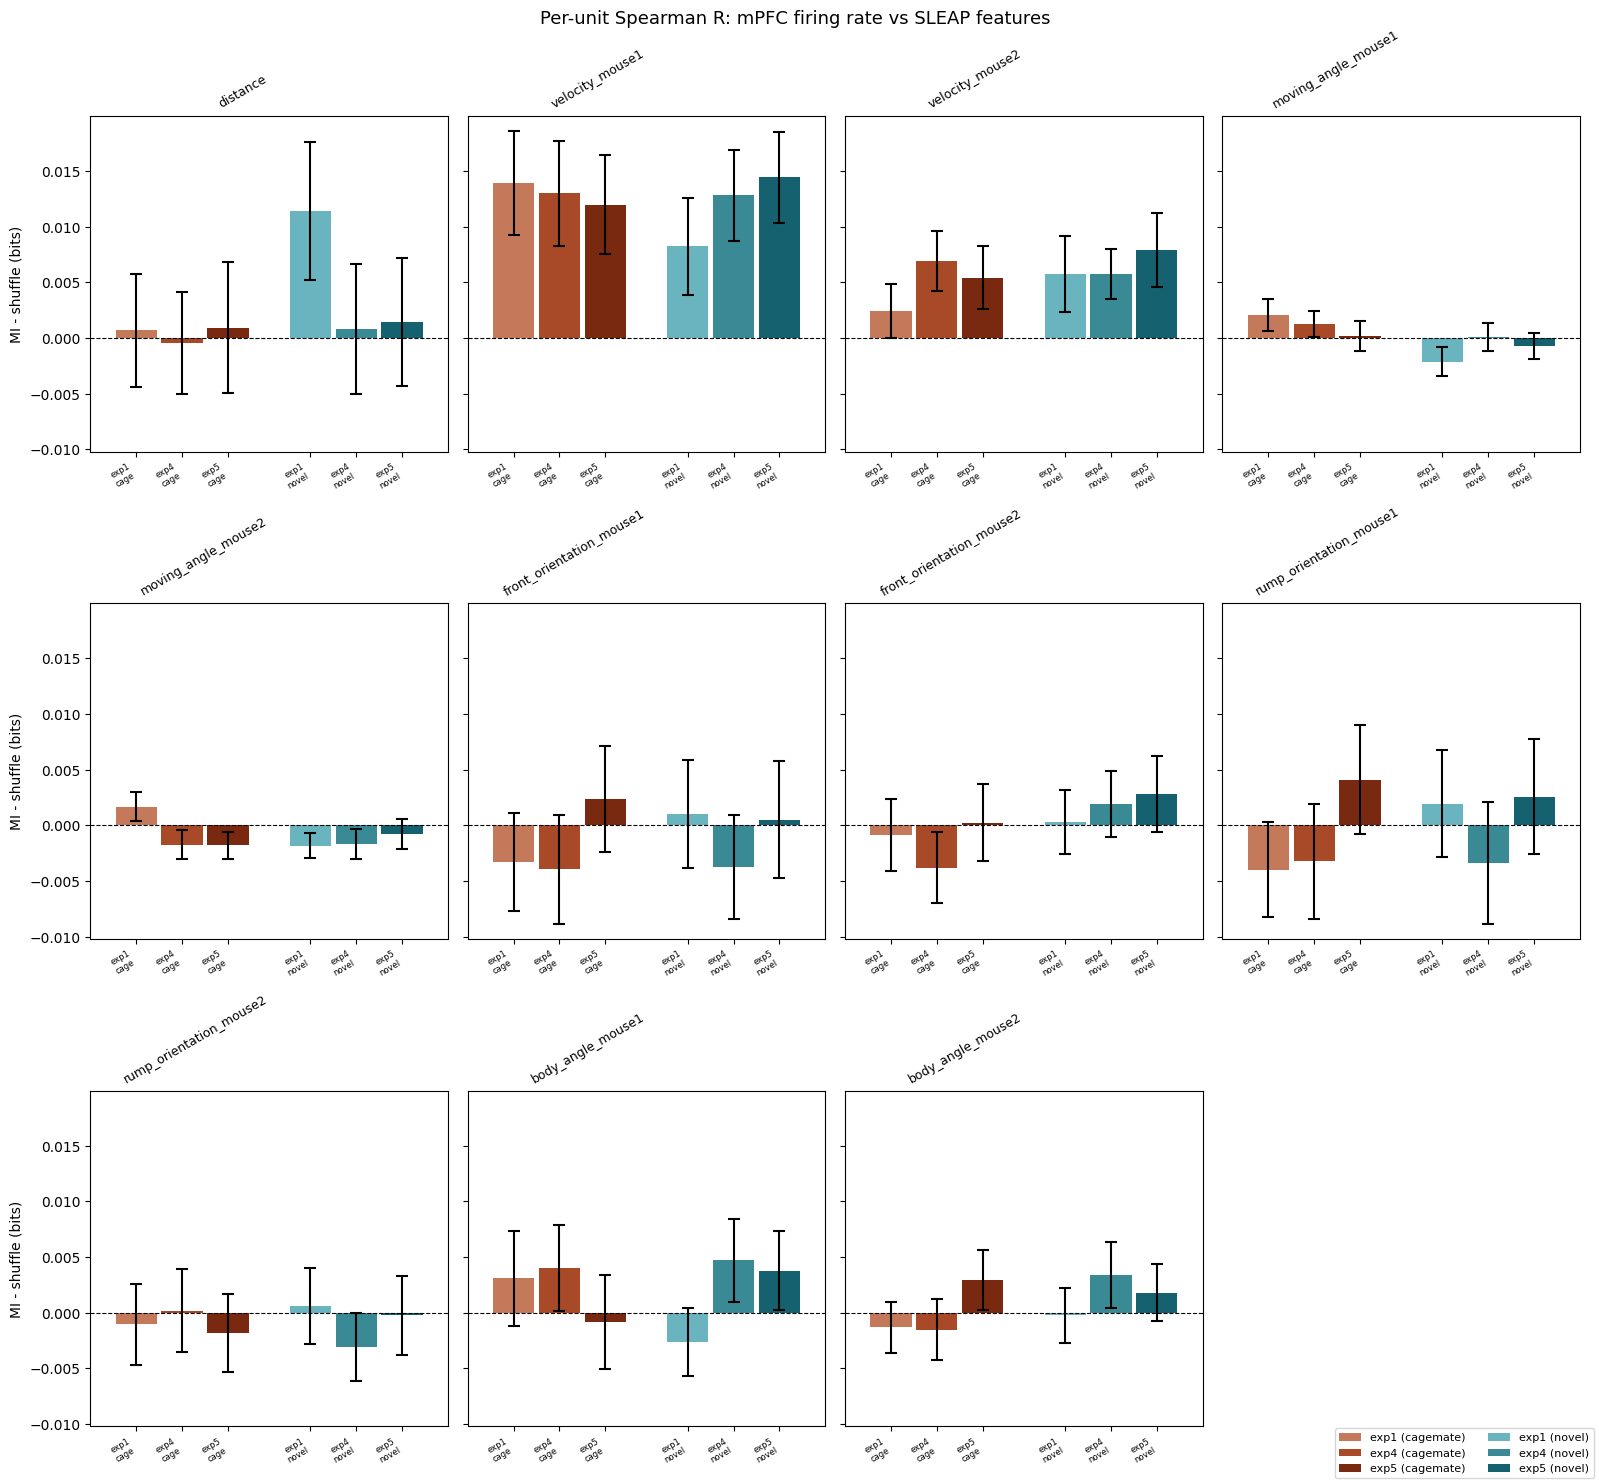

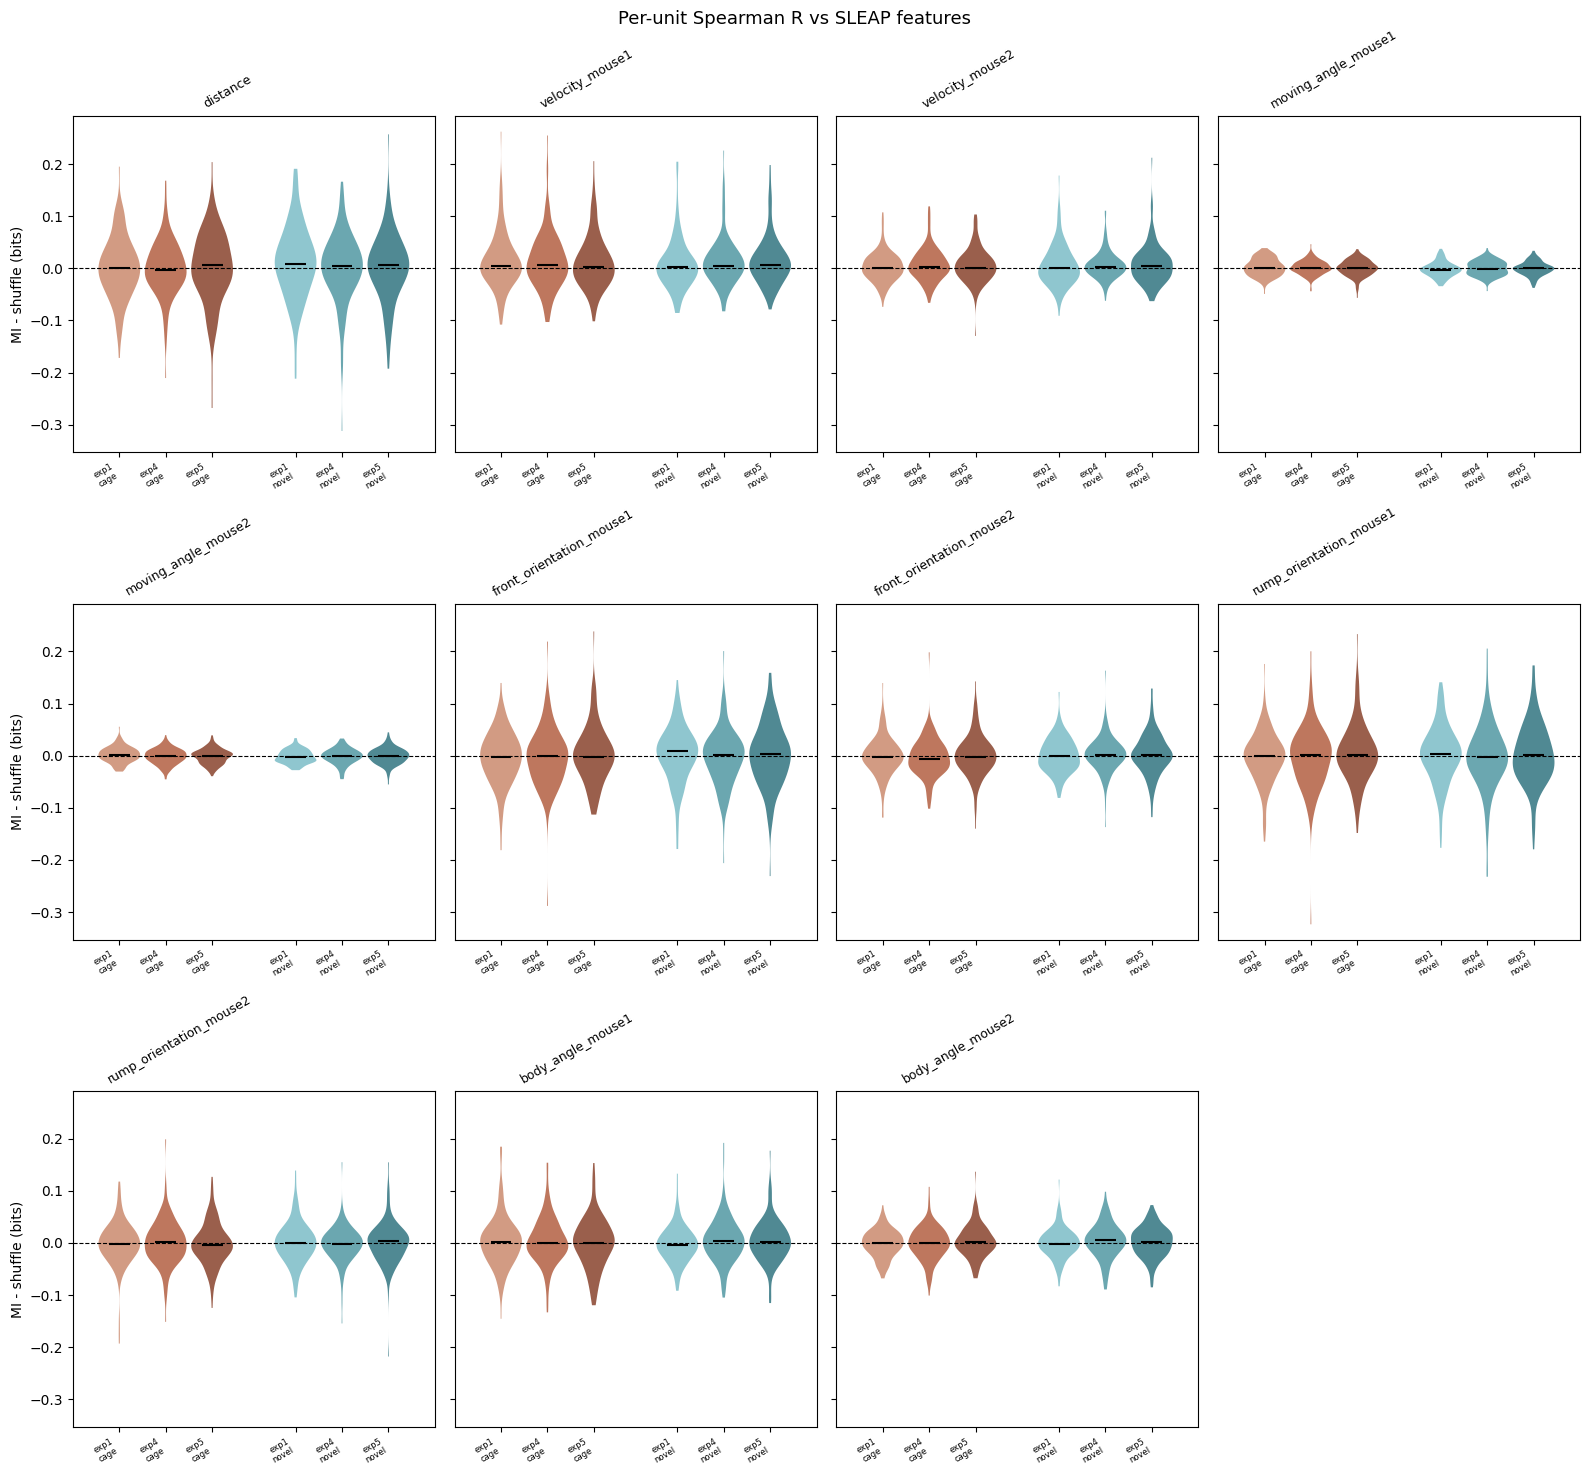

In [13]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

AGENTS     = ['exp1', 'exp4', 'exp5']
# ── colour palettes: light → dark for each condition ──────────────────────────
cage_shades  = ["#c47a5a", "#a84a28", "#792910"]   # light→dark warm brown-red
novel_shades = ["#6ab4bf", "#3a8a96", "#15616F"]   # light→dark teal

# dfs and labels
dfs    = [cage_unit_corr_df,  novel_unit_corr_df]
labels = ['cagemate', 'novel']
all_shades = [cage_shades, novel_shades]

# positions: 3 cage bars, small gap, 3 novel bars
bar_w   = 0.25
gap     = 0.2
cage_positions  = np.array([0, bar_w, bar_w*2])
novel_positions = cage_positions + bar_w*3 + gap
tick_positions  = np.concatenate([cage_positions, novel_positions])
tick_labels     = [f'{ag}\ncage' for ag in AGENTS] + [f'{ag}\nnovel' for ag in AGENTS]

n_cols = min(4, n_features)
n_rows = math.ceil(n_features / n_cols)

# ── BAR PLOT ──────────────────────────────────────────────────────────────────
fig_bar, axes_bar = plt.subplots(n_rows, n_cols,
                                  figsize=(4 * n_cols, 5 * n_rows),
                                  sharey=True)
axes_bar = np.array(axes_bar).flatten()

for ax, feat in zip(axes_bar, features):
    for cond_i, (df, shades) in enumerate(zip(dfs, all_shades)):
        positions = cage_positions if cond_i == 0 else novel_positions
        for ag_i, (agent, shade) in enumerate(zip(AGENTS, shades)):
            vals = df[(df['feature'] == feat) & (df['agent'] == agent)]['spearman_r'].values
            mean = np.nanmean(vals)
            sem  = stats.sem(vals, nan_policy='omit')
            ax.bar(positions[ag_i], mean, yerr=sem, capsize=4,
                   color=shade, width=bar_w * 0.9,
                   error_kw={'elinewidth': 1.5, 'capthick': 1.5},
                   label=f'{agent} ({labels[cond_i]})' if feat == features[0] else None)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=9, rotation=30, ha='right')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=30, ha='right')
    ax.set_xlim(cage_positions[0] - bar_w, novel_positions[-1] + bar_w)

for ax in axes_bar[n_features:]:
    ax.set_visible(False)

for row in range(n_rows):
    axes_bar[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=10)

fig_bar.suptitle('Per-unit Spearman R: mPFC firing rate vs SLEAP features', fontsize=13)
fig_bar.legend(loc='lower right', fontsize=8, framealpha=0.8, ncol=2)
plt.tight_layout()
plt.show()

# ── VIOLIN PLOT ───────────────────────────────────────────────────────────────
fig_vln, axes_vln = plt.subplots(n_rows, n_cols,
                                  figsize=(4 * n_cols, 5 * n_rows),
                                  sharey=True)
axes_vln = np.array(axes_vln).flatten()

for ax, feat in zip(axes_vln, features):
    for cond_i, (df, shades) in enumerate(zip(dfs, all_shades)):
        positions = cage_positions if cond_i == 0 else novel_positions
        data = [df[(df['feature'] == feat) & (df['agent'] == ag)]['spearman_r'].values
                for ag in AGENTS]
        parts = ax.violinplot(data, positions=positions,
                              widths=bar_w * 0.9,
                              showmedians=True, showextrema=False)
        for body, shade in zip(parts['bodies'], shades):
            body.set_facecolor(shade)
            body.set_alpha(0.75)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.5)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=9, rotation=30, ha='right')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=30, ha='right')
    ax.set_xlim(cage_positions[0] - bar_w, novel_positions[-1] + bar_w)

for ax in axes_vln[n_features:]:
    ax.set_visible(False)

for row in range(n_rows):
    axes_vln[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=10)

fig_vln.suptitle('Per-unit Spearman R vs SLEAP features', fontsize=13)
plt.tight_layout()
plt.show()

## MI (shuffle-baselined): per-unit bar

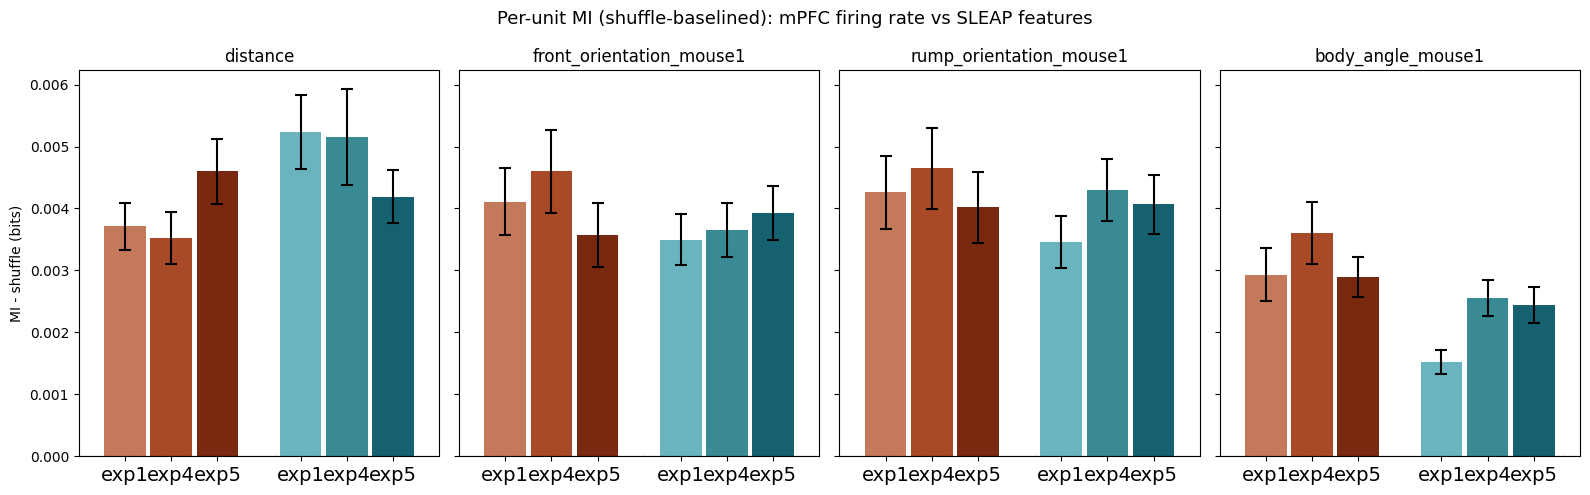

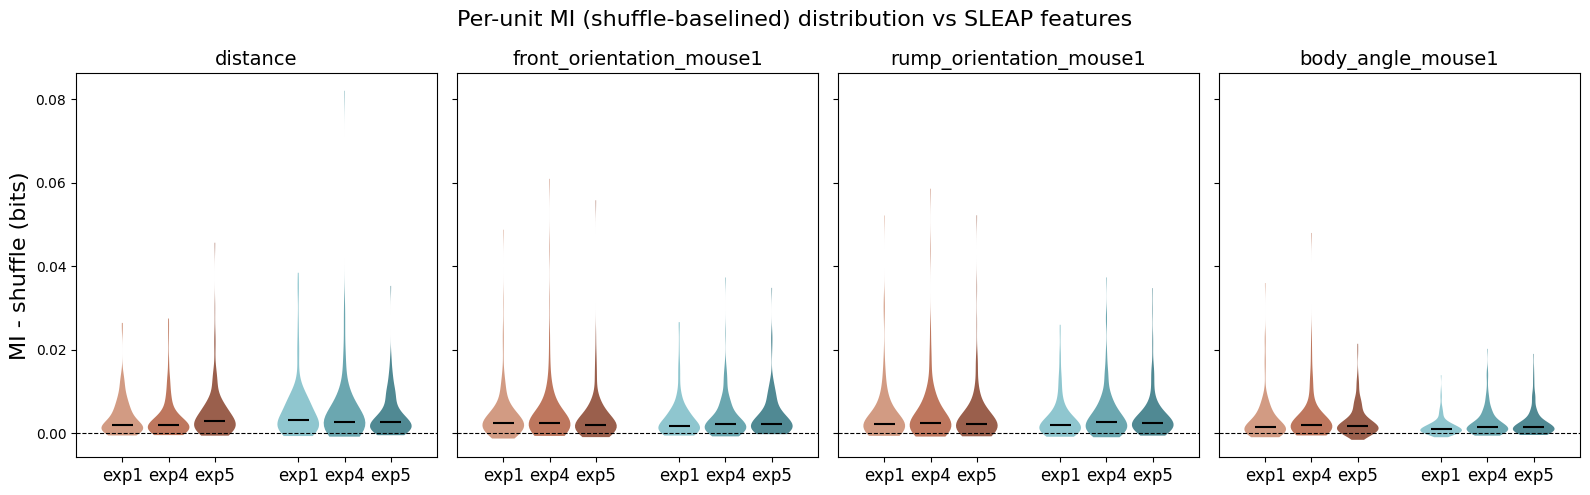

In [38]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

# ── colour palettes: light → dark for each condition ──────────────────────────
cage_shades  = ["#c47a5a", "#a84a28", "#792910"]   # light→dark warm brown-red
novel_shades = ["#6ab4bf", "#3a8a96", "#15616F"]   # light→dark teal

# dfs and labels
dfs    = [cage_unit_mi_df,  novel_unit_mi_df]
labels = ['cagemate', 'novel']
all_shades = [cage_shades, novel_shades]

def plot_mi_two_conditions(df_a, df_b, shades_a, shades_b,
                           features, AGENTS,
                           label_a='condition A', label_b='condition B',
                           title_prefix='Per-unit'):
    n_features = len(features)
    n_cols     = min(4, n_features)
    n_rows     = math.ceil(n_features / n_cols)

    dfs        = [df_a, df_b]
    all_shades = [shades_a, shades_b]
    labels     = [label_a, label_b]

    bar_w       = 0.25
    gap         = 0.2
    pos_a       = np.array([i * bar_w for i in range(len(AGENTS))])
    pos_b       = pos_a + len(AGENTS) * bar_w + gap
    tick_pos    = np.concatenate([pos_a, pos_b])
    tick_labels = ([f'{ag}' for ag in AGENTS] +
                   [f'{ag}' for ag in AGENTS])

    # ── BAR PLOT ──────────────────────────────────────────────────────────────
    fig_bar, axes_bar = plt.subplots(n_rows, n_cols,
                                      figsize=(4 * n_cols, 5 * n_rows),
                                      sharey=True)
    axes_bar = np.array(axes_bar).flatten()

    for ax, feat in zip(axes_bar, features):
        for cond_i, (df, shades) in enumerate(zip(dfs, all_shades)):
            positions = pos_a if cond_i == 0 else pos_b
            for ag_i, (agent, shade) in enumerate(zip(AGENTS, shades)):
                vals = df[(df['feature'] == feat) & (df['agent'] == agent)]['mi'].values
                mean = np.nanmean(vals)
                sem  = stats.sem(vals, nan_policy='omit')
                ax.bar(positions[ag_i], mean, yerr=sem, capsize=4,
                       color=shade, width=bar_w * 0.9,
                       error_kw={'elinewidth': 1.5, 'capthick': 1.5},
                       label=f'{agent} ({labels[cond_i]})' if feat == features[0] else None)

        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(feat, fontsize=12, rotation=0)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, fontsize=14, rotation=0)
        ax.set_xlim(pos_a[0] - bar_w, pos_b[-1] + bar_w)

    for ax in axes_bar[n_features:]:
        ax.set_visible(False)
    for row in range(n_rows):
        axes_bar[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=10)

    fig_bar.suptitle(f'{title_prefix} MI (shuffle-baselined): mPFC firing rate vs SLEAP features',
                     fontsize=13)
    #fig_bar.legend(loc='upper right', fontsize=8, framealpha=0.8, ncol=2)
    plt.tight_layout()
    plt.show()

    # ── VIOLIN PLOT ───────────────────────────────────────────────────────────
    fig_vln, axes_vln = plt.subplots(n_rows, n_cols,
                                      figsize=(4 * n_cols, 5 * n_rows),
                                      sharey=True)
    axes_vln = np.array(axes_vln).flatten()

    for ax, feat in zip(axes_vln, features):
        for cond_i, (df, shades) in enumerate(zip(dfs, all_shades)):
            positions = pos_a if cond_i == 0 else pos_b
            data = [df[(df['feature'] == feat) & (df['agent'] == ag)]['mi'].values
                    for ag in AGENTS]
            parts = ax.violinplot(data, positions=positions,
                                  widths=bar_w * 0.9,
                                  showmedians=True, showextrema=False)
            for body, shade in zip(parts['bodies'], shades):
                body.set_facecolor(shade)
                body.set_alpha(0.75)
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(1.5)

        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(feat, fontsize=14, rotation=0)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_labels, fontsize=12, rotation=0)
        ax.set_xlim(pos_a[0] - bar_w, pos_b[-1] + bar_w)

    for ax in axes_vln[n_features:]:
        ax.set_visible(False)
    for row in range(n_rows):
        axes_vln[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=16)

    fig_vln.suptitle(f'{title_prefix} MI (shuffle-baselined) distribution vs SLEAP features',
                     fontsize=16)
    plt.tight_layout()
    plt.show()

plot_mi_two_conditions(
    df_a         = cage_unit_mi_df,
    df_b         = novel_unit_mi_df,
    shades_a     = ["#c47a5a", "#a84a28", "#792910"],
    shades_b     = ["#6ab4bf", "#3a8a96", "#15616F"],
    features = ['distance', 'front_orientation_mouse1', 'rump_orientation_mouse1', 'body_angle_mouse1'],
    AGENTS       = AGENTS,
    label_a      = 'cagemate',
    label_b      = 'novel',
    title_prefix = 'Per-unit'
)

## MI (shuffle-baselined): population bar + violin

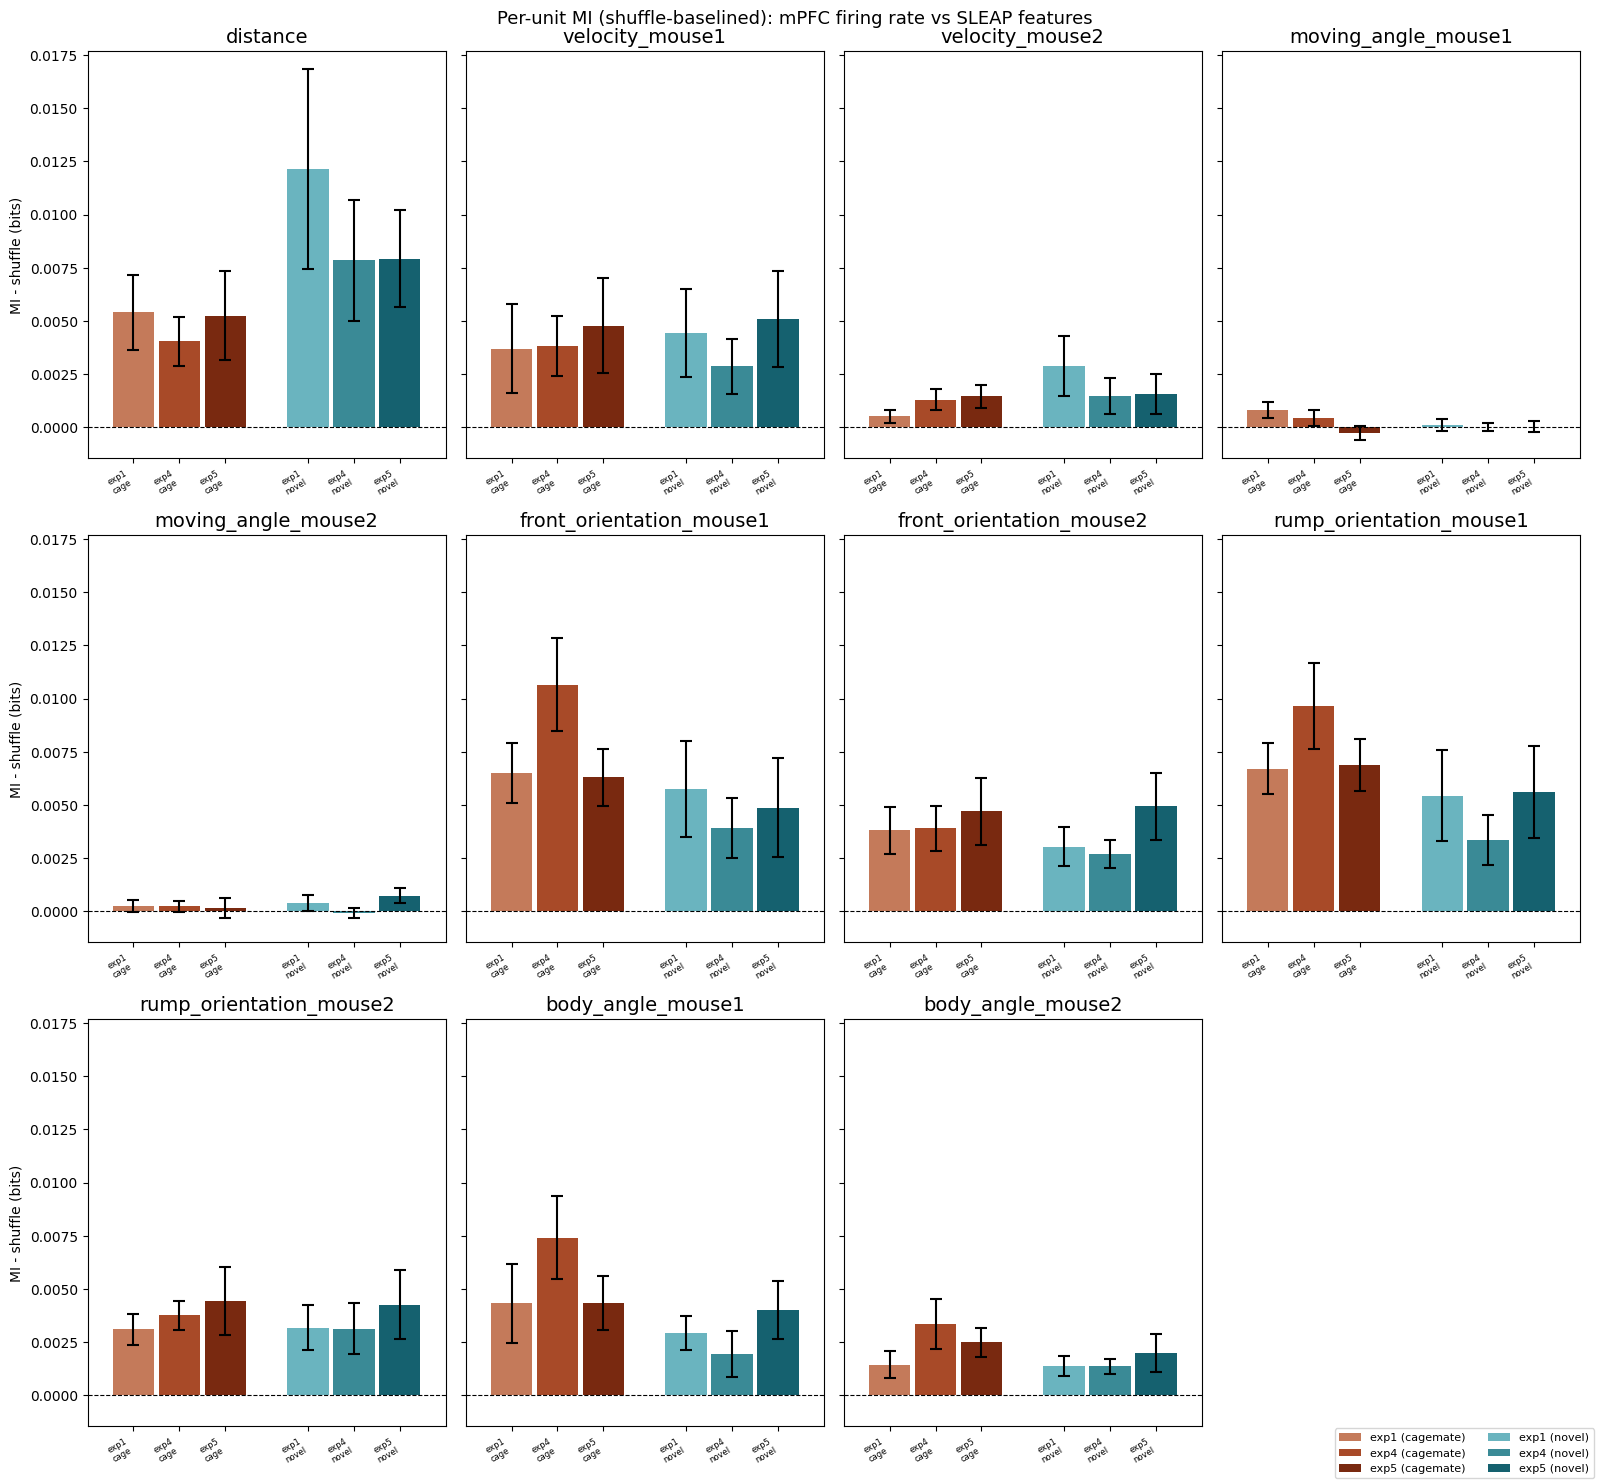

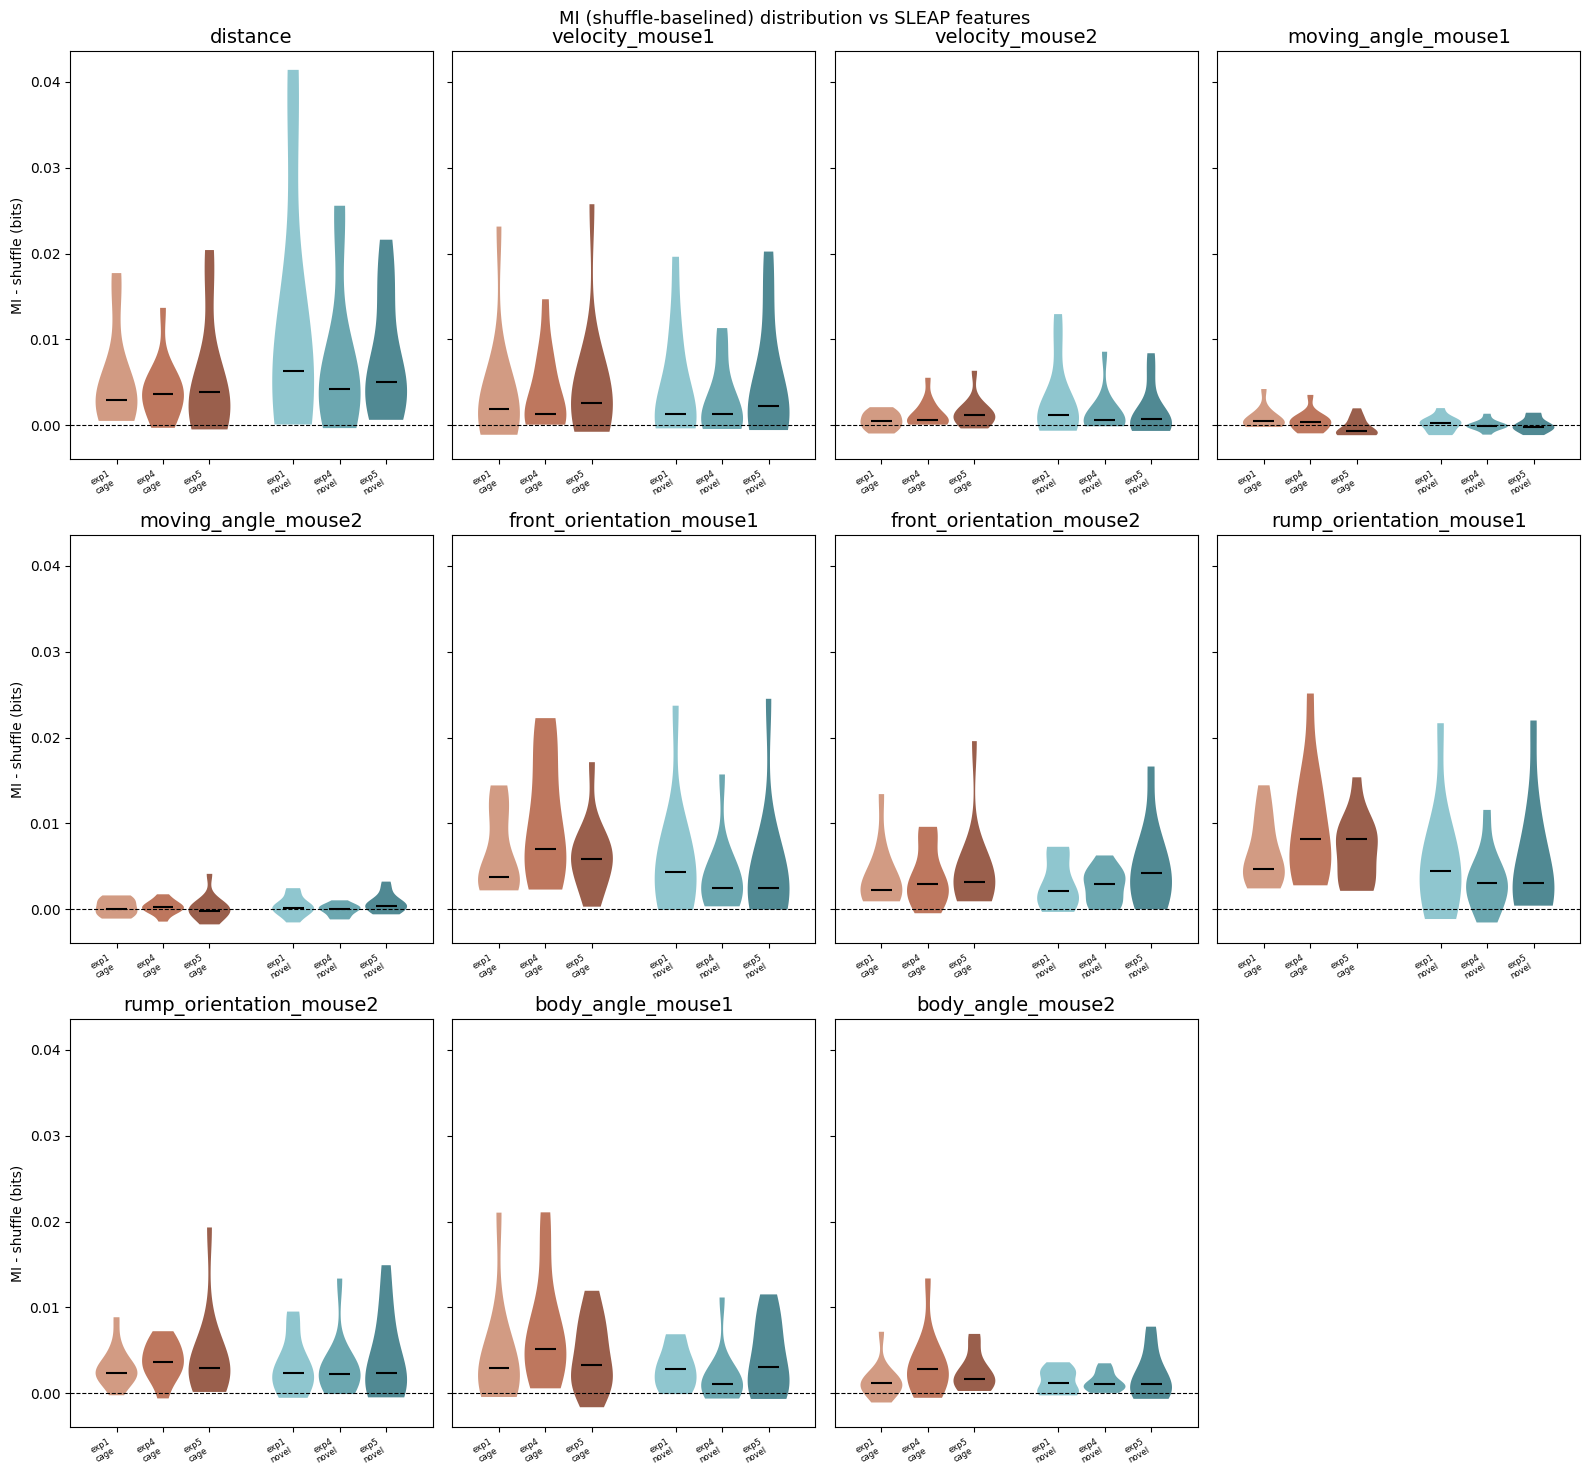

In [25]:
import math
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

# ── colour palettes: light → dark for each condition ──────────────────────────
cage_shades  = ["#c47a5a", "#a84a28", "#792910"]   # light→dark warm brown-red
novel_shades = ["#6ab4bf", "#3a8a96", "#15616F"]   # light→dark teal

# dfs and labels
dfs    = [cage_pop_mi_df,  novel_pop_mi_df]
labels = ['cagemate', 'novel']
all_shades = [cage_shades, novel_shades]

# positions: 3 cage bars, small gap, 3 novel bars
bar_w   = 0.25
gap     = 0.2
cage_positions  = np.array([0, bar_w, bar_w*2])
novel_positions = cage_positions + bar_w*3 + gap
tick_positions  = np.concatenate([cage_positions, novel_positions])
tick_labels     = [f'{ag}\ncage' for ag in AGENTS] + [f'{ag}\nnovel' for ag in AGENTS]

n_cols = min(4, n_features)
n_rows = math.ceil(n_features / n_cols)

# ── BAR PLOT ──────────────────────────────────────────────────────────────────
fig_bar, axes_bar = plt.subplots(n_rows, n_cols,
                                  figsize=(4 * n_cols, 5 * n_rows),
                                  sharey=True)
axes_bar = np.array(axes_bar).flatten()

for ax, feat in zip(axes_bar, features):
    for cond_i, (df, shades) in enumerate(zip(dfs, all_shades)):
        positions = cage_positions if cond_i == 0 else novel_positions
        for ag_i, (agent, shade) in enumerate(zip(AGENTS, shades)):
            vals = df[(df['feature'] == feat) & (df['agent'] == agent)]['mi'].values
            mean = np.nanmean(vals)
            sem  = stats.sem(vals, nan_policy='omit')
            ax.bar(positions[ag_i], mean, yerr=sem, capsize=4,
                   color=shade, width=bar_w * 0.9,
                   error_kw={'elinewidth': 1.5, 'capthick': 1.5},
                   label=f'{agent} ({labels[cond_i]})' if feat == features[0] else None)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=14, rotation=0)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=30, ha='right')
    ax.set_xlim(cage_positions[0] - bar_w, novel_positions[-1] + bar_w)

for ax in axes_bar[n_features:]:
    ax.set_visible(False)

for row in range(n_rows):
    axes_bar[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=10)

fig_bar.suptitle('Per-unit MI (shuffle-baselined): mPFC firing rate vs SLEAP features', fontsize=13)
fig_bar.legend(loc='lower right', fontsize=8, framealpha=0.8, ncol=2)
plt.tight_layout()
plt.show()

# ── VIOLIN PLOT ───────────────────────────────────────────────────────────────
fig_vln, axes_vln = plt.subplots(n_rows, n_cols,
                                  figsize=(4 * n_cols, 5 * n_rows),
                                  sharey=True)
axes_vln = np.array(axes_vln).flatten()

for ax, feat in zip(axes_vln, features):
    for cond_i, (df, shades) in enumerate(zip(dfs, all_shades)):
        positions = cage_positions if cond_i == 0 else novel_positions
        data = [df[(df['feature'] == feat) & (df['agent'] == ag)]['mi'].values
                for ag in AGENTS]
        parts = ax.violinplot(data, positions=positions,
                              widths=bar_w * 0.9,
                              showmedians=True, showextrema=False)
        for body, shade in zip(parts['bodies'], shades):
            body.set_facecolor(shade)
            body.set_alpha(0.75)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.5)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=14, rotation=0)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=30, ha='right')
    ax.set_xlim(cage_positions[0] - bar_w, novel_positions[-1] + bar_w)

for ax in axes_vln[n_features:]:
    ax.set_visible(False)

for row in range(n_rows):
    axes_vln[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=10)

fig_vln.suptitle('MI (shuffle-baselined) distribution vs SLEAP features', fontsize=13)
plt.tight_layout()
plt.show()

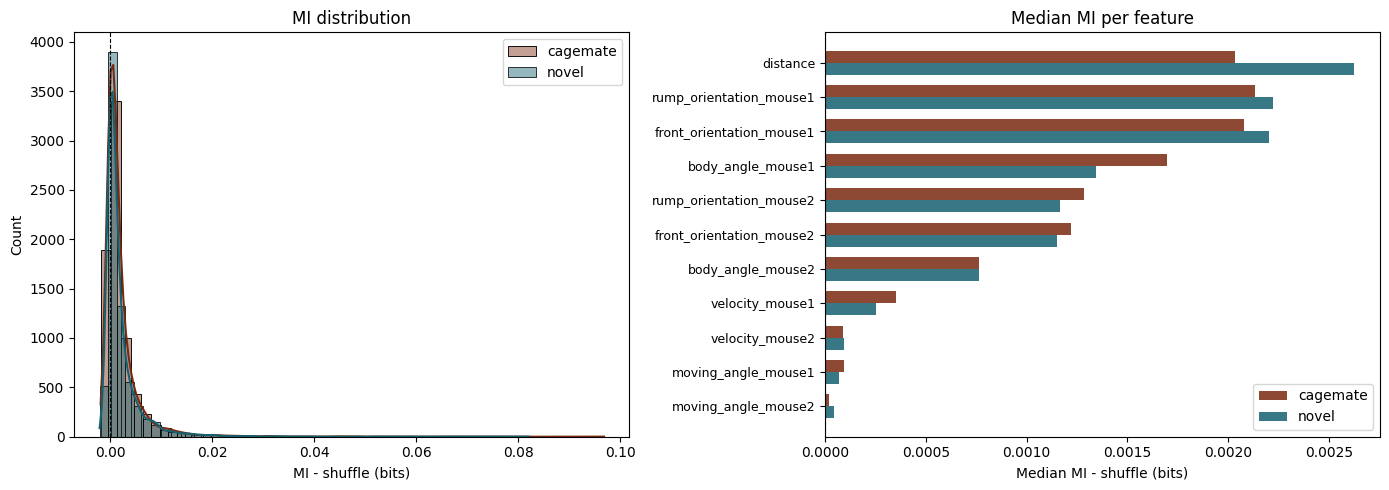


cagemate:
  75th percentile MI: 0.0023
  90th percentile MI: 0.0055
  95th percentile MI: 0.0086
  99th percentile MI: 0.0213

novel:
  75th percentile MI: 0.0023
  90th percentile MI: 0.0055
  95th percentile MI: 0.0087
  99th percentile MI: 0.0186


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── overlapping distributions ─────────────────────────────────────────────────
for df, label, color in zip([cage_unit_mi_df, novel_unit_mi_df],
                              ['cagemate', 'novel'],
                              ['#792910', '#15616F']):
    sns.histplot(df['mi'], bins=50, ax=axes[0],
                 color=color, alpha=0.45, label=label, kde=True)

axes[0].set_title('MI distribution')
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('MI - shuffle (bits)')
axes[0].legend()

# ── paired horizontal bars per feature ───────────────────────────────────────
cage_medians  = cage_unit_mi_df.groupby('feature')['mi'].median()
novel_medians = novel_unit_mi_df.groupby('feature')['mi'].median()

# sort by average median across both conditions
features_sorted = (cage_medians + novel_medians).div(2).sort_values().index

bar_h   = 0.35
y       = np.arange(len(features_sorted))

axes[1].barh(y + bar_h/2, cage_medians[features_sorted],  height=bar_h,
             color='#792910', alpha=0.85, label='cagemate')
axes[1].barh(y - bar_h/2, novel_medians[features_sorted], height=bar_h,
             color='#15616F', alpha=0.85, label='novel')

axes[1].set_yticks(y)
axes[1].set_yticklabels(features_sorted, fontsize=9)
axes[1].set_title('Median MI per feature')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Median MI - shuffle (bits)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── percentiles for both conditions ──────────────────────────────────────────
for label, df in [('cagemate', cage_unit_mi_df), ('novel', novel_unit_mi_df)]:
    print(f"\n{label}:")
    for pct in [75, 90, 95, 99]:
        print(f"  {pct}th percentile MI: {np.percentile(df['mi'], pct):.4f}")

## MI (shuffle-baselined): Venn — units above shuffle per agent

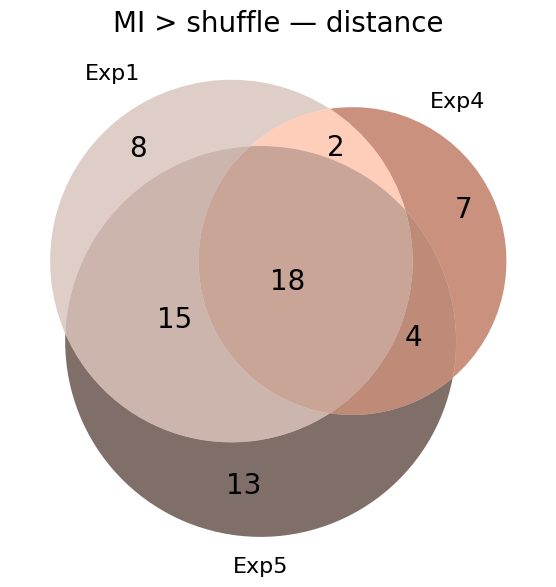

Feature: distance  |  threshold: MI > 0 (above shuffle)
  Cagemate : 43 units
  Familiar : 31 units
  Novel    : 50 units
  All three: 18


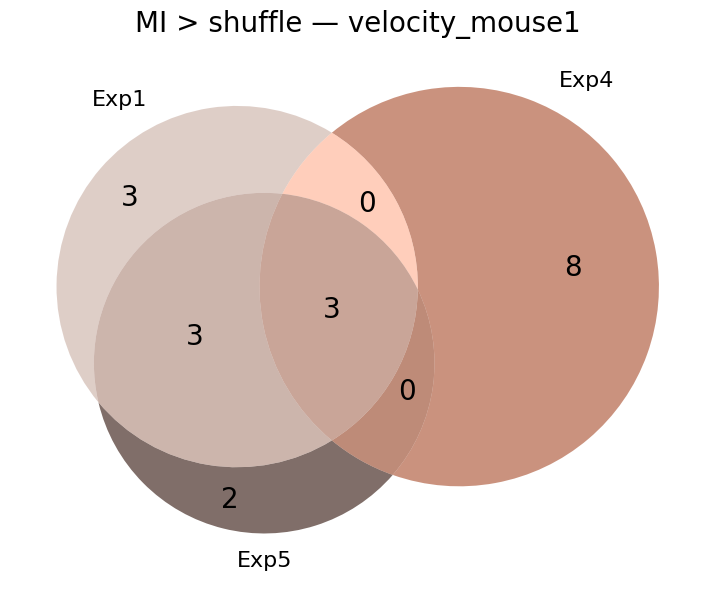

Feature: velocity_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 9 units
  Familiar : 11 units
  Novel    : 8 units
  All three: 3


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:103: UserWarning: Circle A has zero area.
  warnings.warn("Circle A has zero area.")


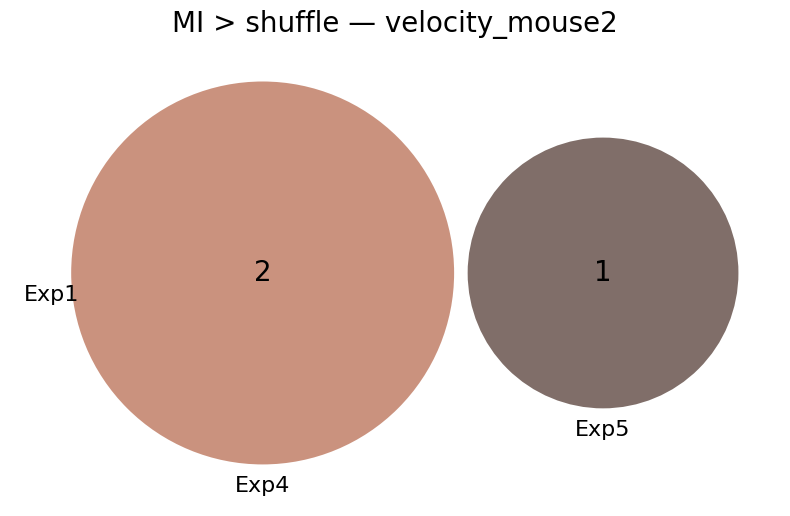

Feature: velocity_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 0 units
  Familiar : 2 units
  Novel    : 1 units
  All three: 0


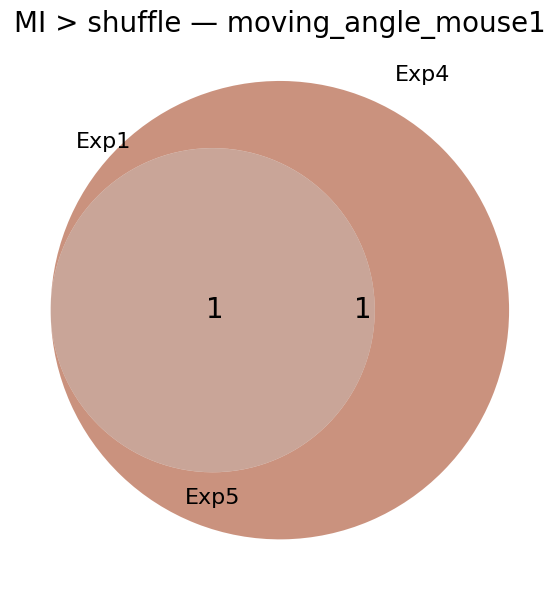

Feature: moving_angle_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 1 units
  Familiar : 2 units
  Novel    : 1 units
  All three: 1


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:97: UserWarning: All circles have zero area.
  warnings.warn("All circles have zero area.")


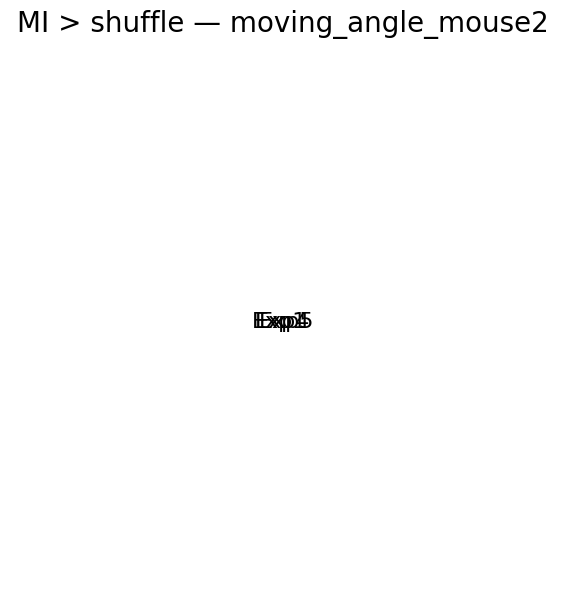

Feature: moving_angle_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 0 units
  Familiar : 0 units
  Novel    : 0 units
  All three: 0


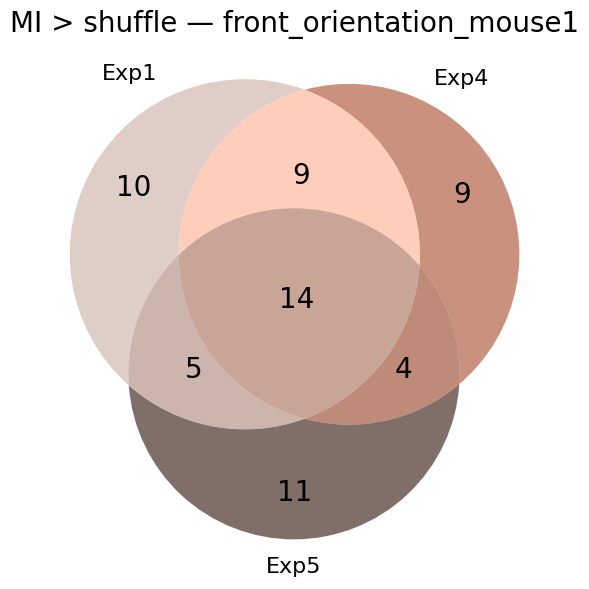

Feature: front_orientation_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 38 units
  Familiar : 36 units
  Novel    : 34 units
  All three: 14


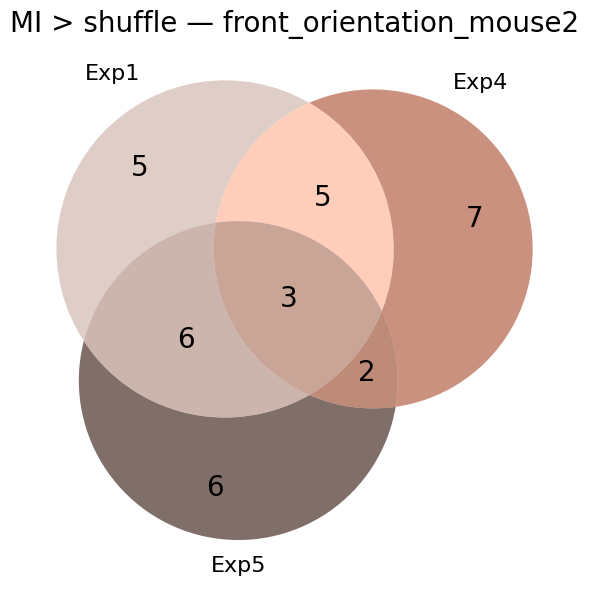

Feature: front_orientation_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 19 units
  Familiar : 17 units
  Novel    : 17 units
  All three: 3


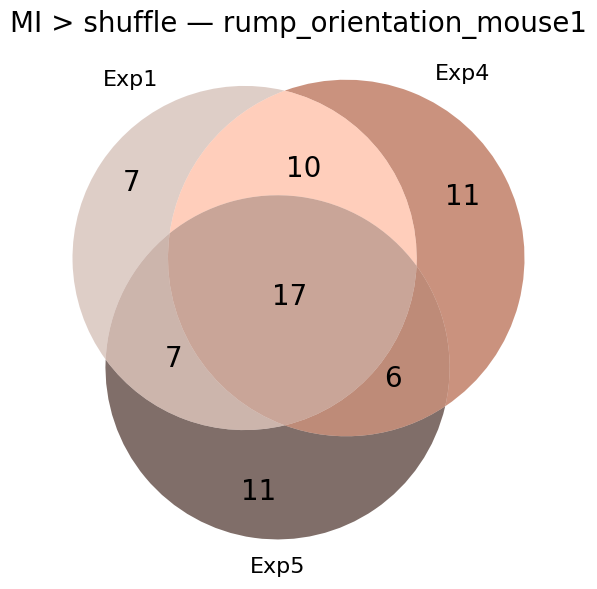

Feature: rump_orientation_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 41 units
  Familiar : 44 units
  Novel    : 41 units
  All three: 17


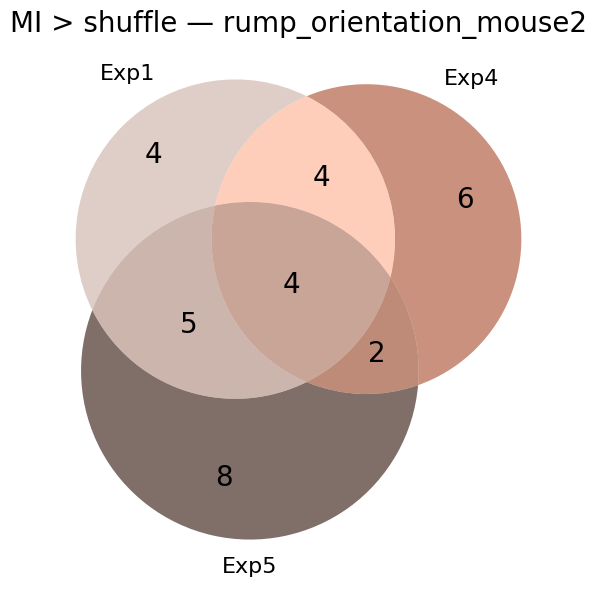

Feature: rump_orientation_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 17 units
  Familiar : 16 units
  Novel    : 19 units
  All three: 4


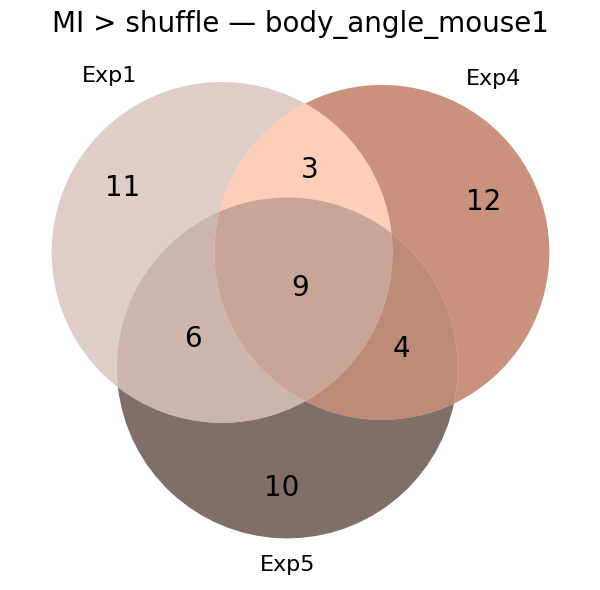

Feature: body_angle_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 29 units
  Familiar : 28 units
  Novel    : 29 units
  All three: 9


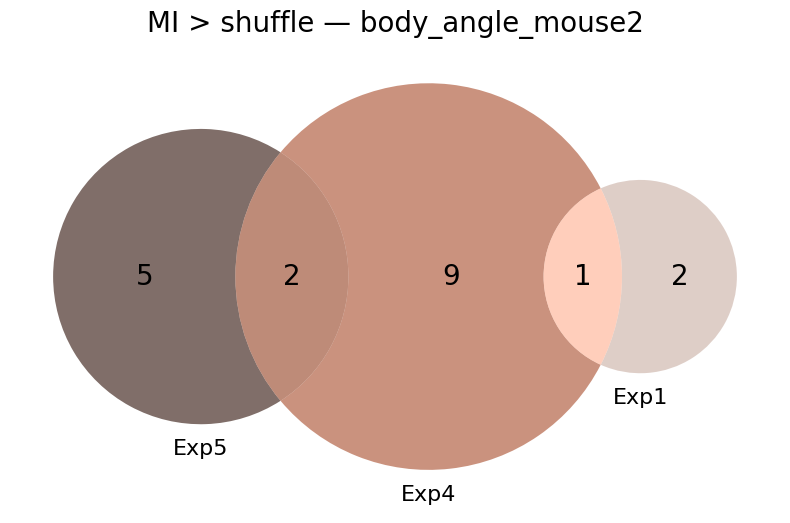

Feature: body_angle_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 3 units
  Familiar : 12 units
  Novel    : 7 units
  All three: 0


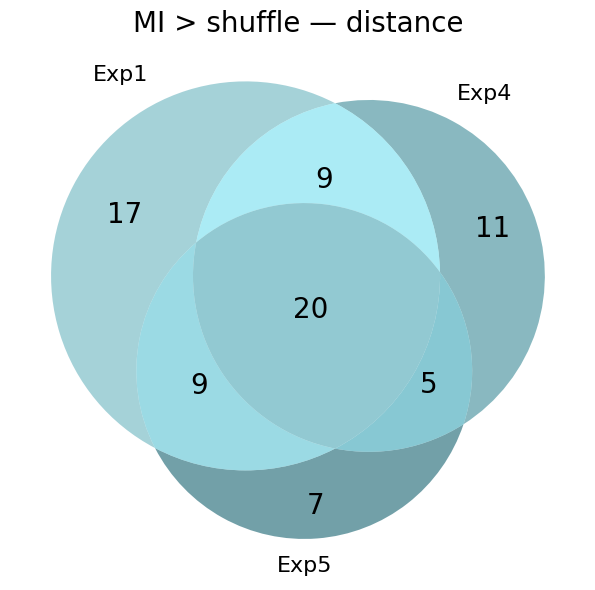

Feature: distance  |  threshold: MI > 0 (above shuffle)
  Cagemate : 55 units
  Familiar : 45 units
  Novel    : 41 units
  All three: 20


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


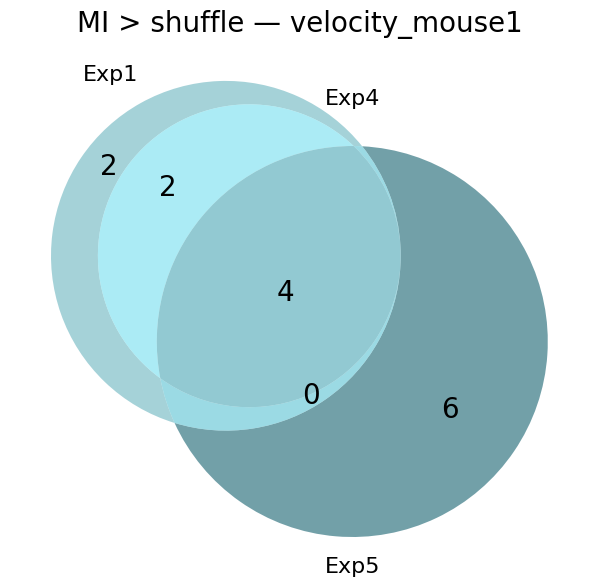

Feature: velocity_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 8 units
  Familiar : 6 units
  Novel    : 10 units
  All three: 4


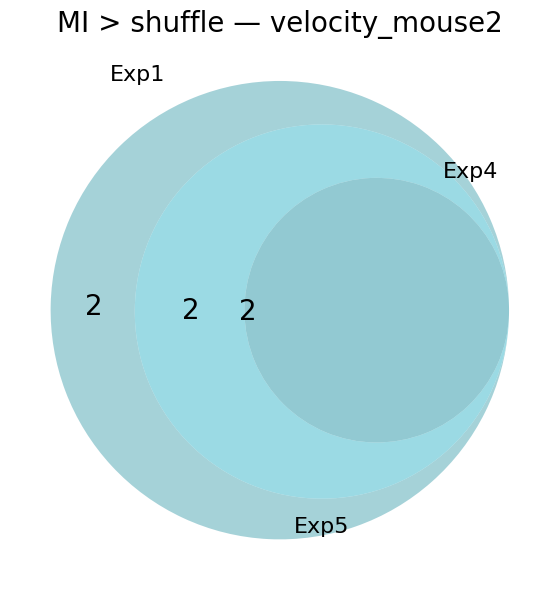

Feature: velocity_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 6 units
  Familiar : 2 units
  Novel    : 4 units
  All three: 2


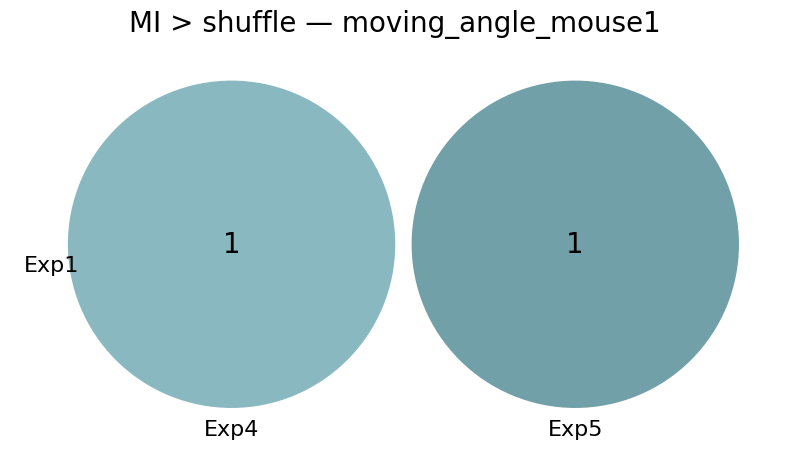

Feature: moving_angle_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 0 units
  Familiar : 1 units
  Novel    : 1 units
  All three: 0


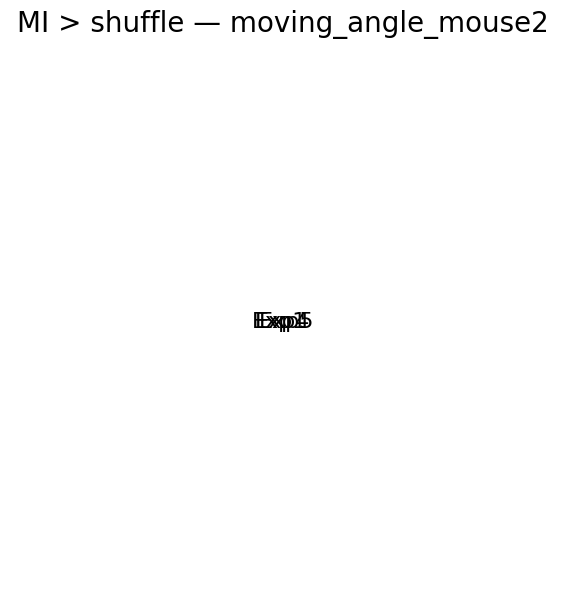

Feature: moving_angle_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 0 units
  Familiar : 0 units
  Novel    : 0 units
  All three: 0


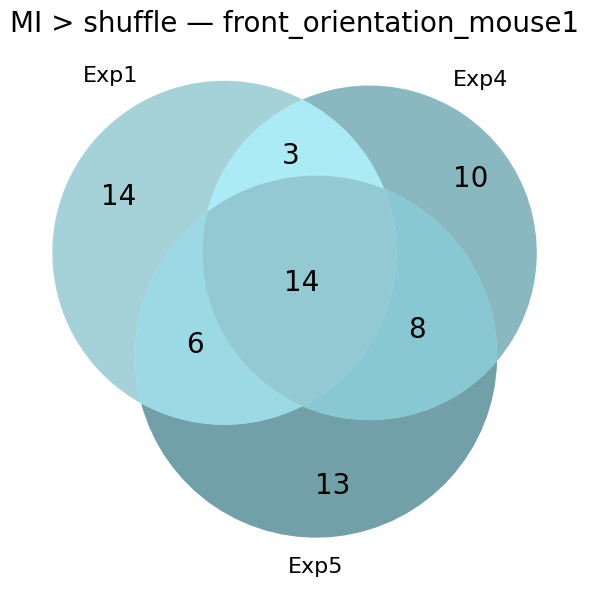

Feature: front_orientation_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 37 units
  Familiar : 35 units
  Novel    : 41 units
  All three: 14


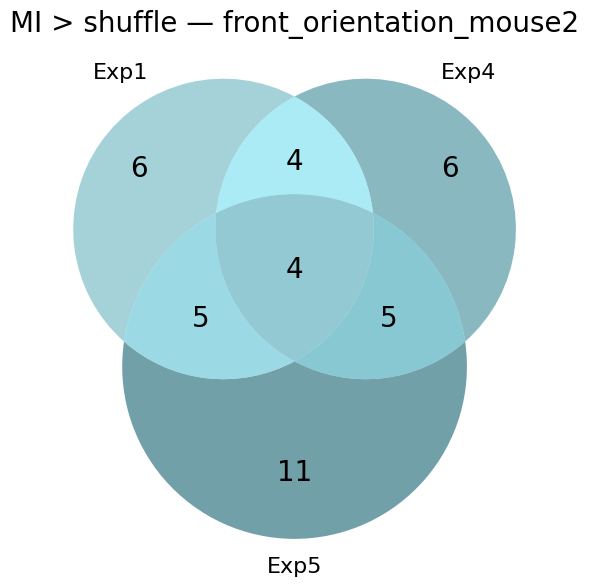

Feature: front_orientation_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 19 units
  Familiar : 19 units
  Novel    : 25 units
  All three: 4


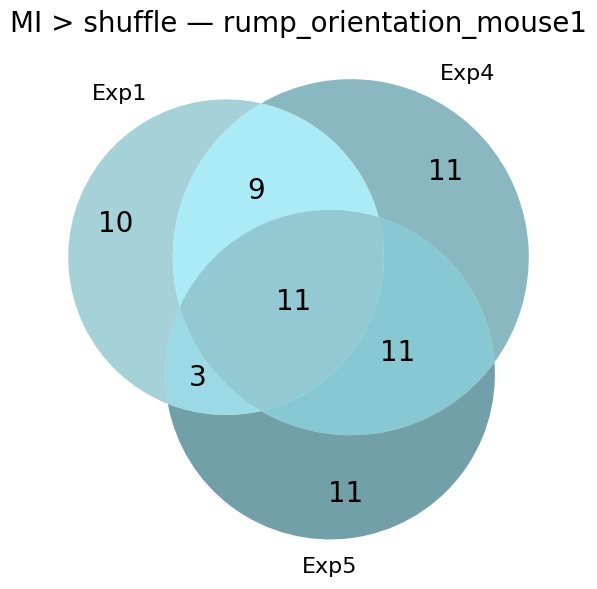

Feature: rump_orientation_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 33 units
  Familiar : 42 units
  Novel    : 36 units
  All three: 11


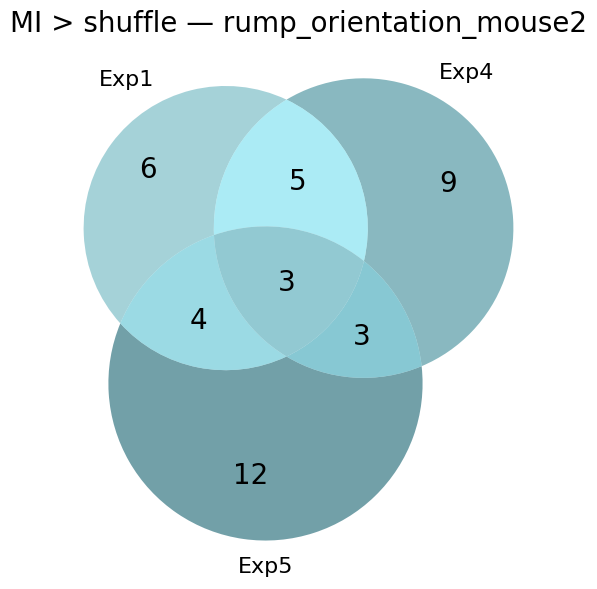

Feature: rump_orientation_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 18 units
  Familiar : 20 units
  Novel    : 22 units
  All three: 3


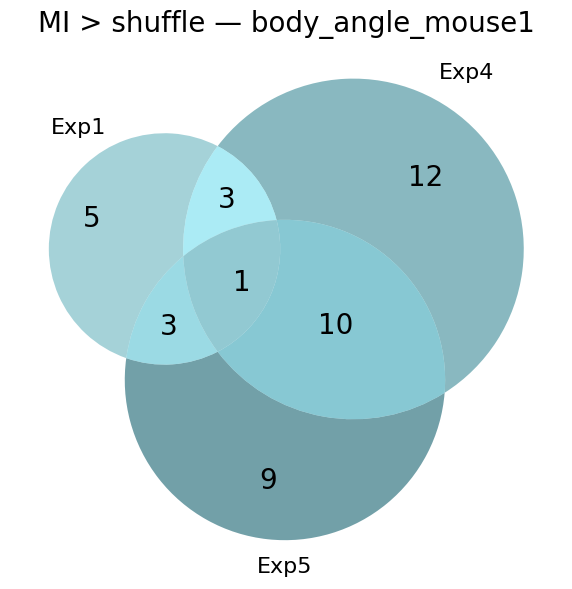

Feature: body_angle_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 12 units
  Familiar : 26 units
  Novel    : 23 units
  All three: 1


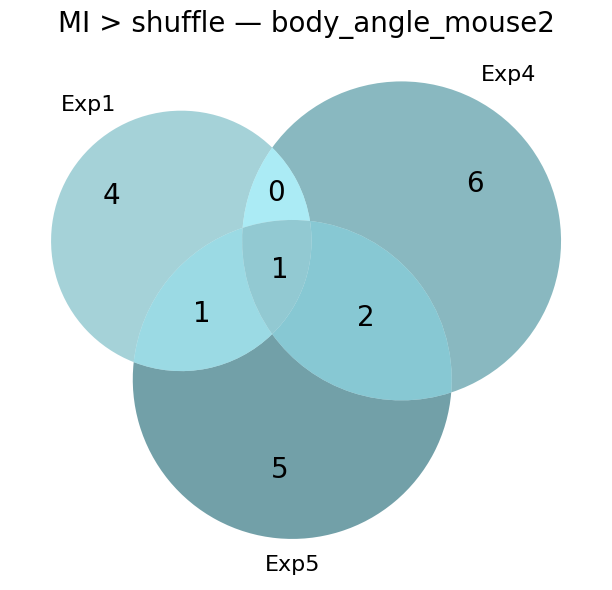

Feature: body_angle_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 6 units
  Familiar : 9 units
  Novel    : 9 units
  All three: 1


In [22]:
## MI Venn — units with positive baselined MI per agent
from matplotlib_venn import venn3
#agent_colors = ['exp1']
agent_colors  = {'exp1': "#c9aea3", 'exp4': "#a84a28", 'exp5': "#2B0E05"}   # light→dark warm brown-red

def plot_mi_venn(unit_mi_df, feature, agent_colors,
                 agent_long='exp1', agent_short='exp4', agent_novel='exp5',
                 title=None):
    df = unit_mi_df[unit_mi_df['feature'] == feature]

    def informative_units(agent):
        mask = (df['agent'] == agent) & (df['mi'] > 0.0043)
        return set(zip(df.loc[mask, 'recording'], df.loc[mask, 'unit_id']))

    set_c = informative_units(agent_long)
    set_f = informative_units(agent_short)
    set_n = informative_units(agent_novel)

    plt.figure(figsize=(8, 6))
    v = venn3([set_c, set_f, set_n],
              set_labels=('Exp1', 'Exp4', 'Exp5'),
              set_colors=(agent_colors[agent_long],
                          agent_colors[agent_short],
                          agent_colors[agent_novel]),
              alpha=0.6)
    for text in (v.set_labels or []):
        if text: text.set_fontsize(16)
    for text in (v.subset_labels or []):
        if text: text.set_fontsize(20)
    plt.title(title or feature, fontsize=20)
    plt.tight_layout()
    plt.show()
    print(f"Feature: {feature}  |  threshold: MI > 0 (above shuffle)")
    print(f"  Cagemate : {len(set_c)} units")
    print(f"  Familiar : {len(set_f)} units")
    print(f"  Novel    : {len(set_n)} units")
    print(f"  All three: {len(set_c & set_f & set_n)}")

for feat in cage_unit_mi_df['feature'].unique():
    plot_mi_venn(cage_unit_mi_df, feat, agent_colors, title=f'MI > shuffle — {feat}')

novel_shades = {"exp1": "#6ab4bf", "exp4": "#3a8a96", "exp5": "#15616F"}
for feat in novel_unit_mi_df['feature'].unique():
    plot_mi_venn(novel_unit_mi_df, feat, novel_shades, title=f'MI > shuffle — {feat}')

In [18]:
from matplotlib_venn import venn3

def plot_tuning_venn(unit_corr_df, feature, threshold,
                     agent_long, agent_short, agent_novel,
                     title=None):
    """
    Venn diagram of units tuned to a given feature across three agents.

    Parameters
    ----------
    unit_corr_df : DataFrame with columns: unit_id, feature, spearman_r, agent
    feature      : str   — value in the 'feature' column to subset on
    threshold    : float — units with |spearman_r| >= threshold are tuned
    agent_long   : str   — agent column value for long-term agent
    agent_short  : str   — agent column value for short-term agent
    agent_novel  : str   — agent column value for novel agent
    title        : str   — plot title (defaults to feature name)
    """
    df = unit_corr_df[unit_corr_df['feature'] == feature]

    def tuned_units(agent):
        try:
            mask = (df['agent'] == agent) & (df['spearman_r'].abs() >= threshold)
        except KeyError:
            mask = (df['agent'] == agent) & (df['mi'].abs() >= threshold)

        return set(df.loc[mask, 'unit_id'])

    set1 = tuned_units(agent_long)
    set2 = tuned_units(agent_short)
    set3 = tuned_units(agent_novel)

    plt.figure(figsize=(8, 6))
    venn = venn3([set1, set2, set3], ('Exp1', 'Exp4', 'Exp5'))

    patch_colors = {
        '100': '#792910',
        '010': '#FFAF00',
        '001': '#15616F',
        '101': '#474640',
    }
    for patch_id, color in patch_colors.items():
        patch = venn.get_patch_by_id(patch_id)
        if patch:
            patch.set_color(color)
            patch.set_alpha(0.7)

    for text in venn.set_labels:
        if text:
            text.set_fontsize(20)
    for text in venn.subset_labels:
        if text:
            text.set_fontsize(28)

    plt.title(title or feature, fontsize=24)
    plt.tight_layout()
    plt.show()

    print(f"Feature: {feature}  |  threshold: |r| >= {threshold}")
    print(f"  Long-term  : {len(set1)} tuned units")
    print(f"  Short-term : {len(set2)} tuned units")
    print(f"  Novel      : {len(set3)} tuned units")
    print(f"  All three  : {len(set1 & set2 & set3)}")

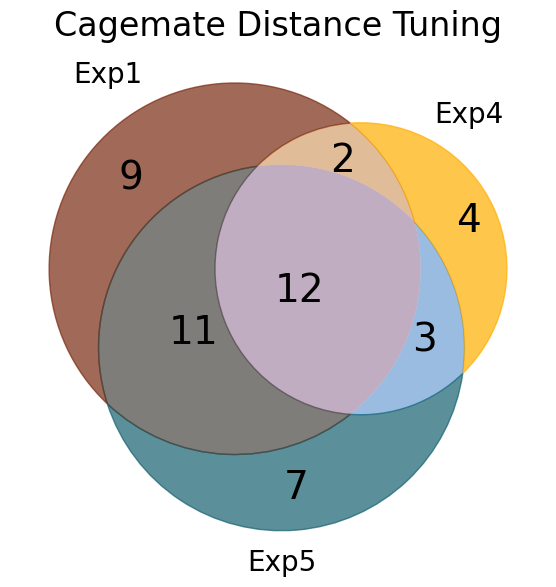

Feature: distance  |  threshold: |r| >= 0.0055
  Long-term  : 34 tuned units
  Short-term : 21 tuned units
  Novel      : 33 tuned units
  All three  : 12


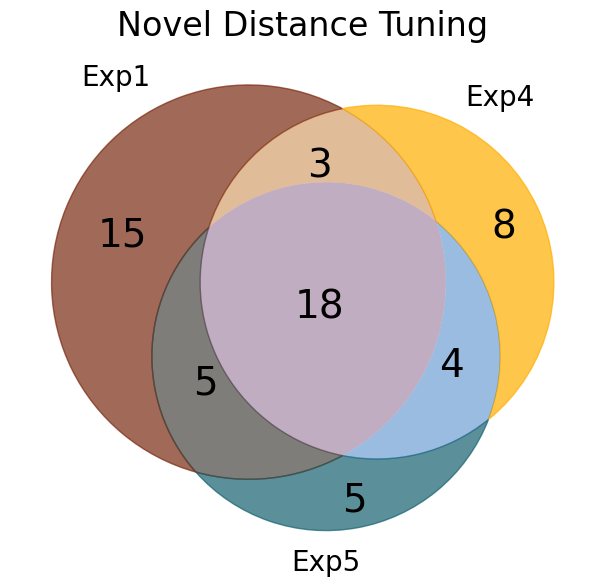

Feature: distance  |  threshold: |r| >= 0.0055
  Long-term  : 41 tuned units
  Short-term : 33 tuned units
  Novel      : 32 tuned units
  All three  : 18


In [19]:
plot_tuning_venn(
    cage_unit_mi_df,
    feature   = 'distance',
    threshold = 0.0055,
    agent_long  = 'exp1',    # whatever your actual column values are
    agent_short = 'exp4',
    agent_novel = 'exp5',
    title = 'Cagemate Distance Tuning'
)

plot_tuning_venn(
    novel_unit_mi_df,
    feature   = 'distance',
    threshold = 0.0055,
    agent_long  = 'exp1',    # whatever your actual column values are
    agent_short = 'exp4',
    agent_novel = 'exp5',
    title = 'Novel Distance Tuning'
)

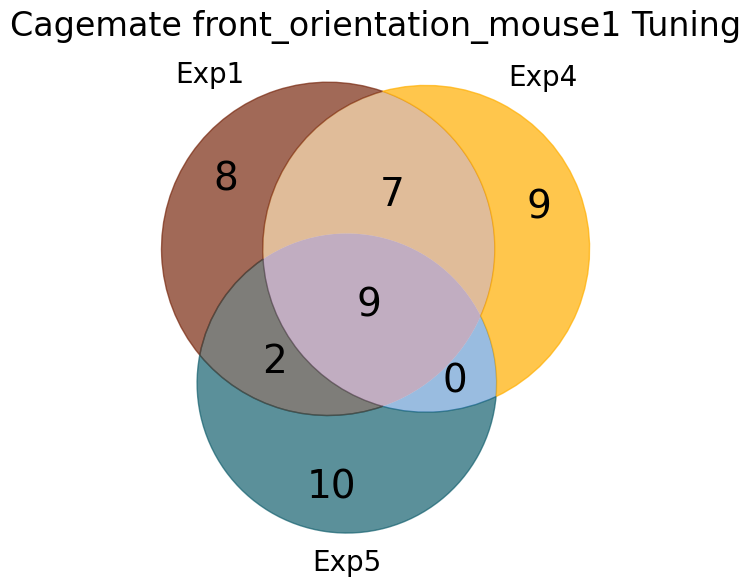

Feature: front_orientation_mouse1  |  threshold: |r| >= 0.0055
  Long-term  : 26 tuned units
  Short-term : 25 tuned units
  Novel      : 21 tuned units
  All three  : 9


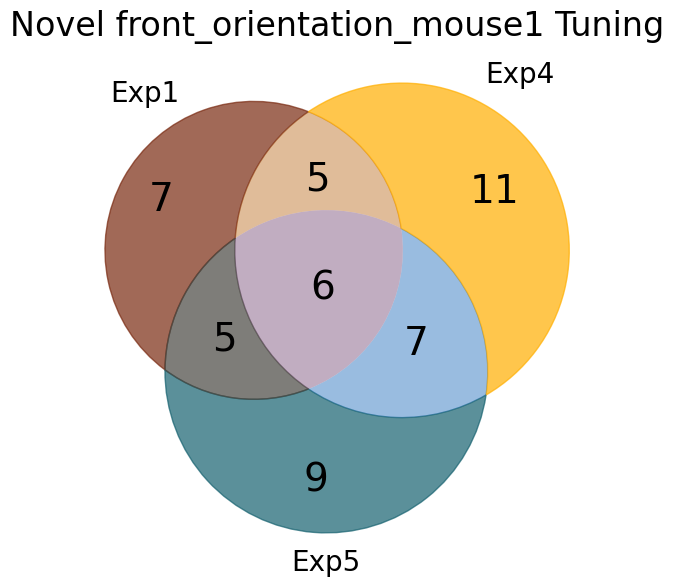

Feature: front_orientation_mouse1  |  threshold: |r| >= 0.0055
  Long-term  : 23 tuned units
  Short-term : 29 tuned units
  Novel      : 27 tuned units
  All three  : 6


In [20]:
plot_tuning_venn(
    cage_unit_mi_df,
    feature   = 'front_orientation_mouse1',
    threshold = 0.0055,
    agent_long  = 'exp1',    # whatever your actual column values are
    agent_short = 'exp4',
    agent_novel = 'exp5',
    title = 'Cagemate front_orientation_mouse1 Tuning'
)

plot_tuning_venn(
    novel_unit_mi_df,
    feature   = 'front_orientation_mouse1',
    threshold = 0.0055,
    agent_long  = 'exp1',    # whatever your actual column values are
    agent_short = 'exp4',
    agent_novel = 'exp5',
    title = 'Novel front_orientation_mouse1 Tuning'
)

In [21]:
plot_tuning_venn(
    unit_corr_df,
    feature   = 'distance',
    threshold = 0.1,
    agent_long  = 'cagemate',    # whatever your actual column values are
    agent_short = 'familiar',
    agent_novel = 'novel',
    title = 'Distance'
)

NameError: name 'unit_corr_df' is not defined

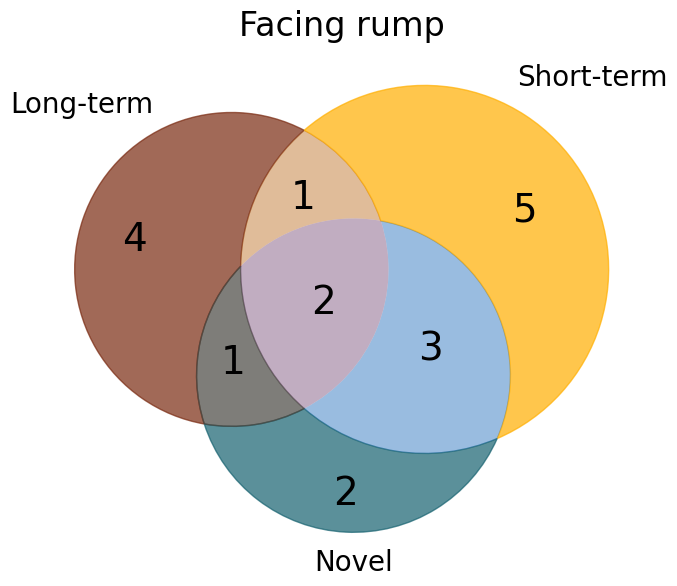

Feature: rump_orientation_mouse1  |  threshold: |r| >= 0.1
  Long-term  : 8 tuned units
  Short-term : 11 tuned units
  Novel      : 8 tuned units
  All three  : 2


In [ ]:
plot_tuning_venn(
    unit_corr_df,
    feature   = 'rump_orientation_mouse1',
    threshold = 0.1,
    agent_long  = 'cagemate',    # whatever your actual column values are
    agent_short = 'familiar',
    agent_novel = 'novel',
    title = 'Facing rump'
)